# scTRAM Benchmarking for HDCA (Human Developmental Cell Atlas)

In [1]:
0

0

In [2]:
import sys

working_directory = "/home/icb/kemal.inecik/work/codes/sctram"
sys.path.append(working_directory)

import gc
import itertools
import logging
import os
import pickle
import subprocess
import sqlite3
import time
import h5py

from pandas.api.types import is_object_dtype
import anndata as ad
import networkx as nx
import numpy as np
import pandas as pd
import scanpy as sc
import tqdm

sc.settings.verbose = 3

In [3]:
from helper.get_hdca_trainings_with_paths import get_hdca_trainings_with_paths
from helper.pickle_operations import save_pickle_bundle, load_pickle_bundle
from helper.csv_operations import (
    harmonize_union_with_report,
    analyze_column_consistency,
    combine_dataframes_on_columns
)

from sctram.api._lower_level import TrajectoryEvaluationAPI
from sctram.generate.real import sc_suo_developmental_complete
from sctram.input import InputTrajectories

sys.path.append("/home/icb/kemal.inecik/work/codes/sctram/reproducibility/server_sync/experiments")
from incremental_training.helper.constants import metrics_scib, metric_direction_dict

2025-08-08 13:37:44.948 | INFO     | sctram.api._defaults_read:load_default_metrics:23 - Loaded default metrics from /home/icb/kemal.inecik/work/codes/sctram/sctram/api/_defaults.yaml
2025-08-08 13:37:44.949 | INFO     | sctram.api._defaults_read:load_default_metrics:79 - Default metrics YAML structure validated successfully.


In [4]:
# Important to have consistent figures across platforms

%matplotlib inline
%config InlineBackend.figure_format='retina'

import pickle

import colorcet as cc
import matplotlib.patheffects as path_effects
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
from matplotlib import gridspec
from networkx.drawing.nx_agraph import graphviz_layout

from networkx.drawing.nx_agraph import graphviz_layout
from matplotlib import gridspec
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches
import seaborn as sns
import colorcet as cc
from matplotlib.ticker import FormatStrFormatter
from adjustText import adjust_text  
import matplotlib.patheffects as path_effects

import matplotlib.cm as cm
import matplotlib.pyplot as plt
import pandas as pd
from plottable import ColumnDefinition, Table
from plottable.cmap import normed_cmap
from plottable.plots import bar

_rcparams_path = os.path.join(working_directory, "reproducibility/figure_rcparams/rcparams.pickle")
with open(_rcparams_path, "rb") as file:
    _rcparams = pickle.load(file)
plt.rcParams.update(_rcparams)

In [5]:
def is_job_running(job_name):
    result = subprocess.run(
        ["squeue", "-o", "%.28i %.28j %.28u %R", "-u", "kemal.inecik"], capture_output=True, text=True
    )
    jobs = [[j.strip() for j in i.split()] for i in result.stdout.strip().split("\n")]
    for jobid, jobname, jobuser, jobnode in jobs:
        if job_name == jobname:
            return True
    return False

In [6]:
os.getcwd()

'/ictstr01/home/icb/kemal.inecik/work/codes/sctram/reproducibility/server_sync/experiments/development_atlas_figure'

In [7]:
dataset_dir = "/home/icb/kemal.inecik/lustre_workspace/temp_sctram_data"
helpers_directory = os.path.join(os.getcwd(), "helper")
logs_directory = os.path.join(os.getcwd(), "logs")

Slurm Settings for reference:

- gpu:
  
    ```
    #SBATCH -J {job_name}
    #SBATCH -p gpu_p
    #SBATCH --qos=gpu_normal
    #SBATCH --gres=gpu:1
    #SBATCH -c 6
    #SBATCH --mem=159G
    #SBATCH --nice=0
    #SBATCH -t 23:50:00
    #SBATCH -o {:log_file}
    #SBATCH -e {log_file}
    ```

- cpu:
  
    ```
    #SBATCH -J {job_name}
    #SBATCH -p cpu_p
    #SBATCH --qos cpu_normal
    #SBATCH -c 32
    #SBATCH --mem=159G
    #SBATCH --nice=0
    #SBATCH -t 1-23:50:00
    #SBATCH -o {log_file}
    #SBATCH -e {log_file}
    ```

## Datasets to Benchmark

In [8]:
df_hdca, df_hdca_lvl2, df_hdca_lvl3 = get_hdca_trainings_with_paths()
df_hdca_lvl3_adata_paths = df_hdca_lvl3.drop_duplicates(subset=["model"], keep='first')[["model", "experiment_id", "dataset"]].copy()
df_hdca_lvl3_adata_paths = {i: {"latent": j, "dataset": k} for i, j, k in list(df_hdca_lvl3_adata_paths.values)}
df_hdca_lvl3_adata_paths

{'scvi': {'latent': '/lustre/groups/ml01/workspace/kemal.inecik/hdca/temp/models/20240613_152640100145_gpusrv44.scidom.de_2367215.h5ad',
  'dataset': '/lustre/groups/ml01/workspace/kemal.inecik/hdca/temp/preprocessing/unification_union_20240330_hvg-intersection_integration.h5ad'},
 'scpoli': {'latent': '/lustre/groups/ml01/workspace/kemal.inecik/hdca/temp/models/20240614_182544898191_gpusrv74.scidom.de_567700.h5ad',
  'dataset': '/lustre/groups/ml01/workspace/kemal.inecik/hdca/temp/preprocessing/unification_union_20240330_hvg-intersection_integration.h5ad'},
 'harmony': {'latent': '/lustre/groups/ml01/workspace/kemal.inecik/hdca/temp/models/harmony_concatenate_unification_union_20240330_hvg-intersection_integration.h5ad',
  'dataset': '/lustre/groups/ml01/workspace/kemal.inecik/hdca/temp/preprocessing/unification_union_20240330_hvg-intersection_integration.h5ad'},
 'pca': {'latent': '/lustre/groups/ml01/workspace/kemal.inecik/hdca/temp/models/pca_unification_union_20240330_hvg_integrat

In [9]:
trajectory_annotation_csv_path = "/home/icb/kemal.inecik/lustre_workspace/hdca/data/metadata/partial_annotation_for_trajectory/update_meta_20250709.csv"
trajectory_annotation_csv = pd.read_csv(trajectory_annotation_csv_path)
trajectory_annotation_csv.set_index("Unnamed: 0", inplace=True)

/tmp/ipykernel_1290869/664984505.py:2: DtypeWarning: Columns (3,6,7,8,15,16,18,20,21,25,26,28,29) have mixed types. Specify dtype option on import or set low_memory=False.
  trajectory_annotation_csv = pd.read_csv(trajectory_annotation_csv_path)


In [10]:
with h5py.File(df_hdca_lvl3_adata_paths["scpoli"]["latent"]) as f:
    adata_scvi_latent_obs = ad.io.read_elem(f["obs"])

In [11]:
out_df, mismatch_df, missing_df = harmonize_union_with_report(trajectory_annotation_csv, adata_scvi_latent_obs)

In [12]:
display(adata_scvi_latent_obs.columns)
display(trajectory_annotation_csv.columns)

Index(['handle_anndata', 'study', 'sample_ID', 'organ', 'age', 'cell_type',
       'integration_donor', 'integration_biological_unit',
       'integration_sample_status', 'integration_library_platform_coarse',
       'concatenated_integration_covariates', 'LVL3', 'LVL2', 'LVL1', 'LVL0',
       '_scvi_batch', '_scvi_labels'],
      dtype='object')

Index(['handle_anndata', 'study', 'sample_ID', 'organ', 'age', 'lane_ID',
       'author_batch', 'institute', 'study_PI', 'integration_donor',
       'integration_biological_unit', 'integration_sample_status',
       'integration_library_platform_coarse', 'anatomical_region',
       'anatomical_region_level_2', 'sex', 'sex_inferred', 'subject_type',
       'sample_status', 'sample_cultured', 'protocol_tissue_dissociation',
       'cell_enrichment', 'library_platform', 'strand_sequence',
       'sequencing_platform', 'reads_processing', 'biological_unit',
       'reference_genome', 'reference_genome_ensembl_release',
       'concatenated_integration_covariates', 'ref_anno2',
       'original_author_annotation', 'ref_anno1', 'broad_anno'],
      dtype='object')

In [13]:
mismatch_df

,sample_ID_new,sample_ID_big
To_HCA_BN_F12482362_and_HCA_BN_F12477274-TTAGGCTAGGACTTAC,2361.0,2361.0
To_HCA_BN_F12482362_and_HCA_BN_F12477274-TTAGGCTAGGAGGACT,2361.0,2361.0
To_HCA_BN_F12482362_and_HCA_BN_F12477274-TTATCCGTCAAAGGCA,2361.0,2361.0
To_HCA_BN_F12482362_and_HCA_BN_F12477274-TTATGACCAATGCGCT,2361.0,2361.0
To_HCA_BN_F12482362_and_HCA_BN_F12477274-TTCACTGTCCTCAGTC,2361.0,2361.0
...,...,...
To_HCA_BN_F13177437_and_HCA_BN_F13177210-TAGGGTTTCGCAAACT,2365.0,2365.0
To_HCA_BN_F13177437_and_HCA_BN_F13177210-TAGGGTTTCTTAGTCT,2365.0,2365.0
To_HCA_BN_F13177437_and_HCA_BN_F13177210-TAGGGTTTCTTAGTGA,2365.0,2365.0
To_HCA_BN_F13177437_and_HCA_BN_F13177210-TAGGTGCGTAGCAGCT,2365.0,2365.0


In [14]:
trajectory_annotation_csv.shape, adata_scvi_latent_obs.shape

((3652086, 34), (3609265, 17))

In [15]:
out_df.shape, mismatch_df.shape, missing_df.shape

((3609265, 34), (180224, 2), (42821, 34))

In [16]:
missing_df.value_counts(['handle_anndata', "broad_anno", "ref_anno1", "ref_anno2"])

handle_anndata  broad_anno                  ref_anno1                           ref_anno2                                
Suo             Fibroblast_mesenchyme       Fibroblast_mesenchyme               Fibroblast_mesenchyme                        19265
                Smooth_muscle               Smooth_muscle                       Smooth_muscle                                 9701
                VSMC_PERICYTE               VSMC_PERICYTE                       VSMC_PERICYTE                                 5008
                Schwann_cell                Schwann_cell_2                      Schwann_cell_2                                3030
                Enteric_glia                Enteric_glia                        Enteric_glia                                  1654
                                                                                                                             ...  
                Lymphatic_endothelial_cell  Lymphatic_endothelial_cell          Lymphatic_en

In [17]:
np.all(out_df.index == adata_scvi_latent_obs.index)

True

In [18]:
out_df = pd.concat([out_df, adata_scvi_latent_obs[['LVL3', 'LVL2', 'LVL1', 'LVL0']].loc[out_df.index]], axis=1)
out_df.columns

Index(['handle_anndata', 'study', 'sample_ID', 'organ', 'age', 'lane_ID',
       'author_batch', 'institute', 'study_PI', 'integration_donor',
       'integration_biological_unit', 'integration_sample_status',
       'integration_library_platform_coarse', 'anatomical_region',
       'anatomical_region_level_2', 'sex', 'sex_inferred', 'subject_type',
       'sample_status', 'sample_cultured', 'protocol_tissue_dissociation',
       'cell_enrichment', 'library_platform', 'strand_sequence',
       'sequencing_platform', 'reads_processing', 'biological_unit',
       'reference_genome', 'reference_genome_ensembl_release',
       'concatenated_integration_covariates', 'ref_anno2',
       'original_author_annotation', 'ref_anno1', 'broad_anno', 'LVL3', 'LVL2',
       'LVL1', 'LVL0'],
      dtype='object')

### Training the Atlas Components

In [19]:
job_count = 0
overwrite = False

cpu_gpu = "gpu"
df_hdca_component_adata_paths = dict()

with h5py.File(df_hdca_lvl3_adata_paths["scvi"]["dataset"]) as f:
    unique_handle_anndata = ad.io.read_elem(f["obs/handle_anndata"]).unique()

for handle_anndata in unique_handle_anndata:
    
    for model_str in ["scvi"]:
        
        adata_file_path = "/lustre/groups/ml01/workspace/kemal.inecik/hdca/temp/preprocessing/unification_union_20240330_hvg-intersection_integration.h5ad"
        trained_model_path = f"/lustre/groups/ml01/workspace/kemal.inecik/hdca/temp/models/unification_union_20240330_hvg-intersection_integration_{handle_anndata}_scvi"
        trained_latent_path = f"/lustre/groups/ml01/workspace/kemal.inecik/hdca/temp/models/unification_union_20240330_hvg-intersection_integration_{handle_anndata}_scvi.h5ad"

        log_file = os.path.join(logs_directory, f"scvi_component_{cpu_gpu}_{model_str}_{handle_anndata}.log")
        job_name = f"prep_{model_str}_{handle_anndata}"
        python_name = f"scvi_individual.py"

        if is_job_running(job_name):
            print(f"Training {job_name!r} on {cpu_gpu!r} keeps going.")
        elif overwrite or not os.path.exists(trained_latent_path) or not os.path.isfile(trained_latent_path):
            try:
                slurm_script = f"""#!/bin/bash
#SBATCH -J {job_name}
#SBATCH -p gpu_p
#SBATCH --qos=gpu_normal
#SBATCH --gres=gpu:1
#SBATCH -c 18
#SBATCH --mem=481G
#SBATCH --nice=0
#SBATCH -t 23:50:00
#SBATCH -o {log_file}
#SBATCH -e {log_file}

source activate hdca_integration_env
python -u {os.path.join(helpers_directory, python_name)} --adata_file_path "{adata_file_path}" --trained_model_path "{trained_model_path}" --trained_latent_path "{trained_latent_path}" --handle_anndata "{handle_anndata}"
    """
                script_name = os.path.join(logs_directory, f"slurm_job_scvi_component_{cpu_gpu}_{model_str}_{handle_anndata}.sh")
                with open(script_name, "w") as f:
                    f.write(slurm_script)

                print(f"Submitted job {job_count+1}: {job_name!r}")
                subprocess.run(["sbatch", script_name])
                job_count += 1
            finally:
                # time.sleep(0.05)
                os.remove(script_name)

            assert is_job_running(job_name), f"Training {job_name!r} on {cpu_gpu!r} error."
        else:
            print(f"Model exists for {model_str!r} of {handle_anndata!r}")

        df_hdca_component_adata_paths[handle_anndata] = {"latent": trained_latent_path, "dataset": adata_file_path}
    # if job_count > 32:
    #     break

print(f" - Number of jobs submitted: {job_count}")

Model exists for 'scvi' of 'Braun'
Model exists for 'scvi' of 'Calvanese'
Model exists for 'scvi' of 'Colin'
Model exists for 'scvi' of 'Dong'
Model exists for 'scvi' of 'Garcia'
Model exists for 'scvi' of 'He'
Model exists for 'scvi' of 'Kanemaru'
Model exists for 'scvi' of 'Lawrence'
Model exists for 'scvi' of 'Miller'
Model exists for 'scvi' of 'Sridhar'
Model exists for 'scvi' of 'Suo'
Model exists for 'scvi' of 'To'
Model exists for 'scvi' of 'Yu'
Model exists for 'scvi' of 'Zhang'
 - Number of jobs submitted: 0


In [20]:
df_hdca_component_adata_paths

{'Braun': {'latent': '/lustre/groups/ml01/workspace/kemal.inecik/hdca/temp/models/unification_union_20240330_hvg-intersection_integration_Braun_scvi.h5ad',
  'dataset': '/lustre/groups/ml01/workspace/kemal.inecik/hdca/temp/preprocessing/unification_union_20240330_hvg-intersection_integration.h5ad'},
 'Calvanese': {'latent': '/lustre/groups/ml01/workspace/kemal.inecik/hdca/temp/models/unification_union_20240330_hvg-intersection_integration_Calvanese_scvi.h5ad',
  'dataset': '/lustre/groups/ml01/workspace/kemal.inecik/hdca/temp/preprocessing/unification_union_20240330_hvg-intersection_integration.h5ad'},
 'Colin': {'latent': '/lustre/groups/ml01/workspace/kemal.inecik/hdca/temp/models/unification_union_20240330_hvg-intersection_integration_Colin_scvi.h5ad',
  'dataset': '/lustre/groups/ml01/workspace/kemal.inecik/hdca/temp/preprocessing/unification_union_20240330_hvg-intersection_integration.h5ad'},
 'Dong': {'latent': '/lustre/groups/ml01/workspace/kemal.inecik/hdca/temp/models/unificat

##  Trajectories to Benchmark

In [21]:
ground_truth_trajectories = dict()

In [22]:
# Define the input dictionary
ground_truth_trajectories = dict()
ground_truth_trajectories_annotation_level = dict()

# ref_anno2
ground_truth_trajectories_annotation_level["germline"] = "ref_anno2"
ground_truth_trajectories["germline"] = [
    ('PGC', 'GC'),
    ('GC', 'pre_spermatogonia'),
    ('GC', 'oogonia'),
    ('oogonia', 'oogonia_meiotic_1'),
    ('oogonia_meiotic_1', 'oogonia_meiotic_2'),
    ('oogonia_meiotic_2', 'pre_oocyte'),
    ('pre_oocyte', 'oocyte')
]

# ref_anno2
ground_truth_trajectories_annotation_level["pns_neuro"] = "ref_anno2"
ground_truth_trajectories["pns_neuro"] = [
    ('ANC/SCP', 'Autonomic_neuronal_progenitor'),
    ('Autonomic_neuronal_progenitor', 'Enteric_like_neuronal_progenitor'),
    ('Enteric_like_neuronal_progenitor','Enteric_neuron'),
    ('Enteric_like_neuronal_progenitor','Enteric_neuron_like'),
    ('Autonomic_neuronal_progenitor', 'Parasympathetic_neuron_progenitor'),
    ('Autonomic_neuronal_progenitor', 'Sympathetic_neuronal_progenitor'),
    ('Parasympathetic_neuron_progenitor', 'Parasympathetic_neuron_1'),
    ('Parasympathetic_neuron_progenitor', 'Parasympathetic_neuron_2'),
    ('Sympathetic_neuronal_progenitor', 'Sympathetic_neuron_transitioning'),
    ('Sympathetic_neuron_transitioning', 'Sympathetic_neuron'),
    ('Sympathetic_neuronal_progenitor', 'Chromaffin_cell'),
]

# ref_anno1
ground_truth_trajectories_annotation_level["pns_glia"] = "ref_anno1"
ground_truth_trajectories["pns_glia"] = [
    ('ANC/SCP', 'Enteric_glia'),
    ('ANC/SCP', 'SCP'),
    ('SCP', 'Schwann_cell_1'),
    ('SCP', 'Schwann_cell_2'),
    ('SCP', 'Schwann_cell_3'),
    ('SCP', 'Schwann_cell_4'),
    ('SCP', 'Schwann_cell_5'),
]

# broad_anno
ground_truth_trajectories_annotation_level["Haem_broad"] = "broad_anno"
ground_truth_trajectories['Haem_broad'] = [
    ('Haematopoietic_Progenitor', 'B_cell'),
    ('Haematopoietic_Progenitor', 'EOSINOPHIL_BASOPHIL'),
    ('Haematopoietic_Progenitor', 'Erythroid'),
    ('Haematopoietic_Progenitor', 'ILC'),
    ('Haematopoietic_Progenitor', 'MAST_CELL'),
    ('Haematopoietic_Progenitor', 'MK'),
    ('Haematopoietic_Progenitor', 'Monocyte'),
    ('Monocyte', 'Macrophage'),
    ('Haematopoietic_Progenitor', 'DC'),
    ('Haematopoietic_Progenitor', 'Myelocyte'),
    ('Myelocyte', 'Neutrophil'),
    ('Haematopoietic_Progenitor', 'T_cell'),
    ('Haematopoietic_Progenitor', 'NK'),
]

# ref_anno1
ground_truth_trajectories_annotation_level["Ery"] = "ref_anno1"
ground_truth_trajectories['Ery'] = [
    ('HSC_MPP', 'MEMP_MEP'),
    ('MEMP_MEP', 'Erythroid_1'),
    ('Erythroid_1', 'Erythroid_2'),
    ('Erythroid_2', 'Erythroid_3'),
    ('Erythroid_3', 'Erythroid_4'),
    ('Erythroid_4', 'Erythroid_5'),
    ('Erythroid_5', 'Erythroid_6'),
# exclude erythroids 7 8 and 9
]

# ref_anno1
ground_truth_trajectories_annotation_level["B_lin"] = "ref_anno1"
ground_truth_trajectories['B_lin'] = [
    ('HSC_MPP', 'LMPP_MLP'),
    ('LMPP_MLP', 'Pre_pro_B'),
    ('Pre_pro_B', 'Pro_B'),
    ('Pro_B', 'Late_Pro_B'),
    ('Late_Pro_B', 'Large_pre_B'),
    ('Large_pre_B', 'Small_pre_B'),
    ('Small_pre_B', 'Immature_B'),
    ('Immature_B', 'Mature_B'),
    ('Mature_B', 'B1'),
    ('Mature_B', 'Plasma_B'),
]

# ref_anno1
ground_truth_trajectories_annotation_level["Haem_ref"] = "ref_anno1"
ground_truth_trajectories['Haem_ref'] = [
    
    # HSCs
    ('HSC_MPP', 'LMPP_MLP'),
    
    # MEM - exclude erythroid 6,7,8,9, MEM_like
    ('HSC_MPP', 'MEMP_MEP'),
    ('MEMP_MEP', 'Erythroid_1'),
    ('Erythroid_1', 'Erythroid_2'),
    ('Erythroid_2', 'Erythroid_3'),
    ('Erythroid_3', 'Erythroid_4'),
    ('Erythroid_4', 'Erythroid_5'),
    
    
    ('MEMP_MEP', 'MK_non_classical'),
    ('MEMP_MEP', 'Early_MK'),
    ('Early_MK', 'Late_MK'),
    
    ('CMP', 'EOSINOPHIL_BASOPHIL'),
    ('CMP', 'MAST_CELL'),
    
    
    # Myeloid - exclude Macrophage_ery, Macrophage_YS_like_iron_recycling, microglia
    ('HSC_MPP', 'CMP'),
    ('CMP', 'PROMYELOCYTE'),
    ('PROMYELOCYTE', 'Myelocyte'),
    ('Myelocyte', 'Neutrophil'),
    
    ('CMP', 'MOP_PROMONOCYTE'),
    ('MOP_PROMONOCYTE', 'Monocyte'),
    ('Monocyte', 'Langerhan_cells'),
    ('Monocyte', 'Macrophage_FOLR2_SPP1'),
    ('Monocyte', 'Macrophage_Kuffer_like'),
    ('Monocyte', 'Macrophage_LYVE1'),
    ('Monocyte', 'Macrophage_brain_like_non_microglia'),
    ('Monocyte', 'Macrophage_gut_unique'),
    ('Monocyte', 'Macrophage_iron_recycling'),
    ('Monocyte', 'Osteoclast_like_macrophages'),
    
    # DC - exclue pDC
    ('CMP', 'DC'),
    ('CMP', 'DC1'),
    ('DC', 'Migratory_DC'),
    ('DC1', 'Migratory_DC'),
    
    # B lineage
    ('LMPP_MLP', 'Pre_pro_B'),
    ('Pre_pro_B', 'Pro_B'),
    ('Pro_B', 'Late_Pro_B'),
    ('Late_Pro_B', 'Large_pre_B'),
    ('Large_pre_B', 'Small_pre_B'),
    ('Small_pre_B', 'Immature_B'),
    ('Immature_B', 'Mature_B'),
    ('Mature_B', 'B1'),
    ('Mature_B', 'Plasma_B'),
    ('Mature_B', 'CYCLING_B'),
    
    # T lineage - original paper determine P as younger proliferative and Q as older 
    ('HSC_MPP', 'LMPP_MLP'),
    ('LMPP_MLP', 'DN(early)_T'),
    ('DN(early)_T', 'DN(P)_T'),
    ('DN(P)_T', 'DN(Q)_T'),
    ('DN(Q)_T', 'DP(P)_T'),
    ('DP(P)_T', 'DP(Q)_T'),
    ('DP(Q)_T', 'ABT(ENTRY)'),
    ('ABT(ENTRY)', 'CD4_T'),
    ('ABT(ENTRY)', 'CD8_T'),
    ('ABT(ENTRY)', 'CYCLING_T'),
    ('ABT(ENTRY)', 'CD8AA'),
    ('ABT(ENTRY)', 'TYPE_1_INNATE_T'),
    ('ABT(ENTRY)', 'TYPE_3_INNATE_T'),
    ('CD4_T', 'TREG'),
    ('CD8_T', 'TREG'),
    
    # ILC
    ('LMPP_MLP', 'ILC2'),
    ('LMPP_MLP', 'ILC3'),
    
    # NK
    ('LMPP_MLP', 'NK'),
    ('NK', 'CYCLING_NK'),

]

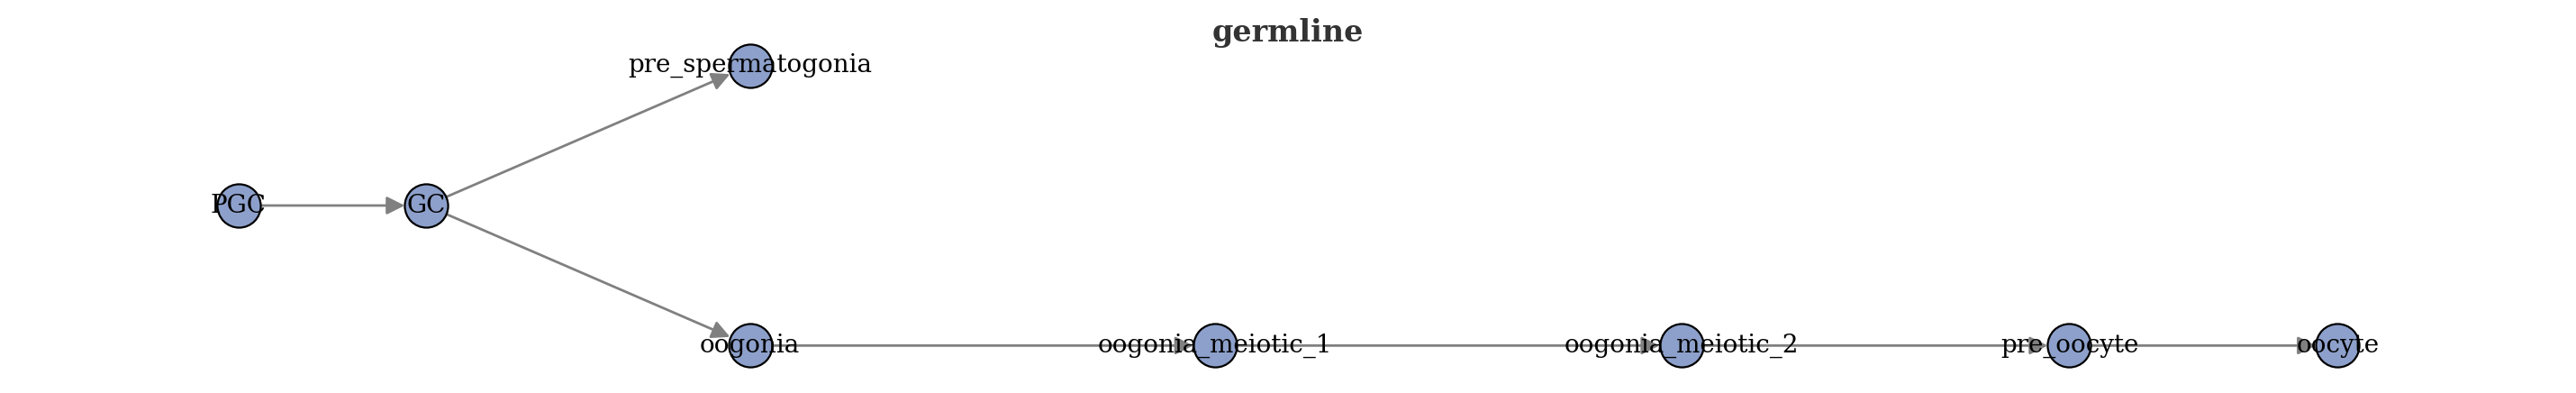

[]

In [23]:
trajectory = "germline"
_input_trajectory = InputTrajectories(ground_truth_trajectories).get_trajectory(trajectory, include_additional_nodes=True)
_input_trajectory.plot_trajectory(
    title=trajectory,
    figsize=(15, 2), 
    label_offset=0,
)
un = np.unique(out_df[ground_truth_trajectories_annotation_level[trajectory]])
[n for n in _input_trajectory.nodes() if n not in un]

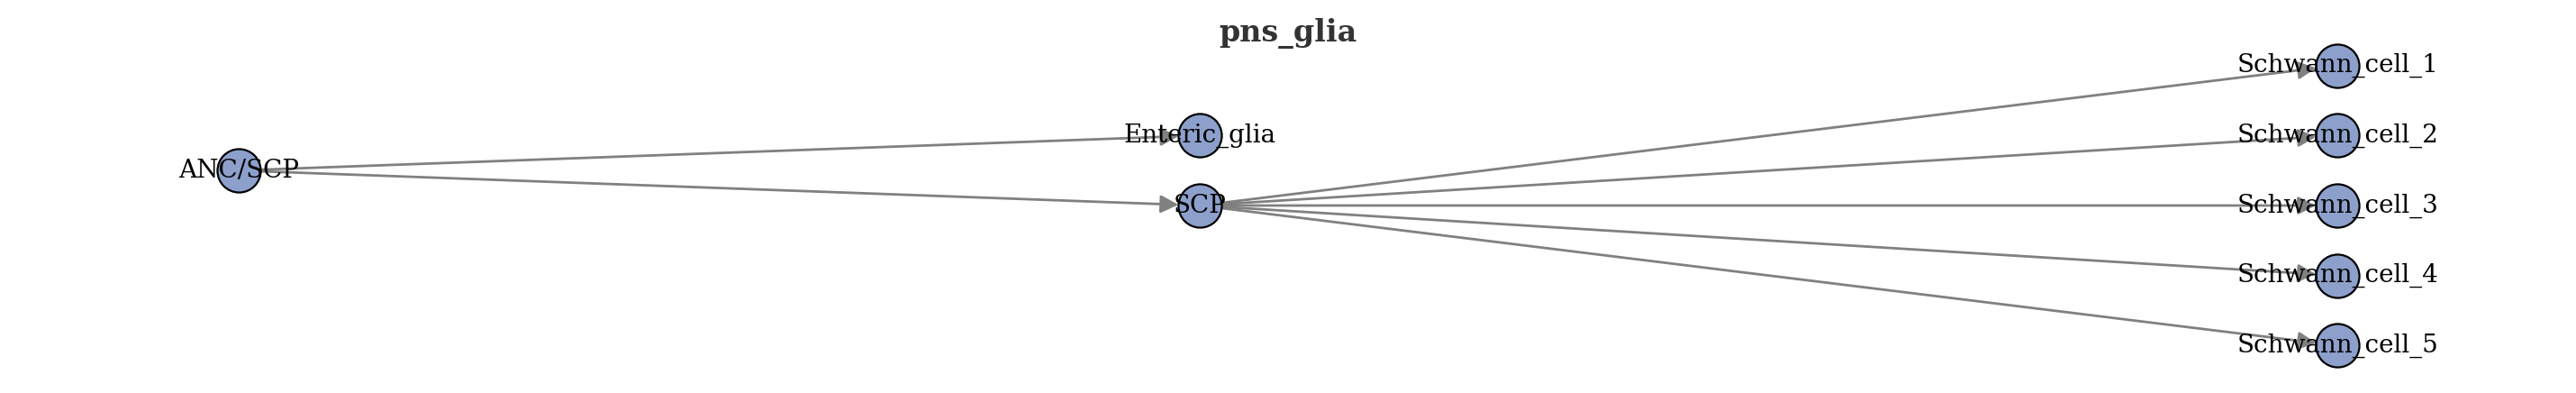

[]

In [24]:
trajectory = "pns_glia"
_input_trajectory = InputTrajectories(ground_truth_trajectories).get_trajectory(trajectory, include_additional_nodes=True)
_input_trajectory.plot_trajectory(
    title=trajectory,
    figsize=(15, 2), 
    label_offset=0,
)
un = np.unique(out_df["ref_anno1"])
[n for n in _input_trajectory.nodes() if n not in un]

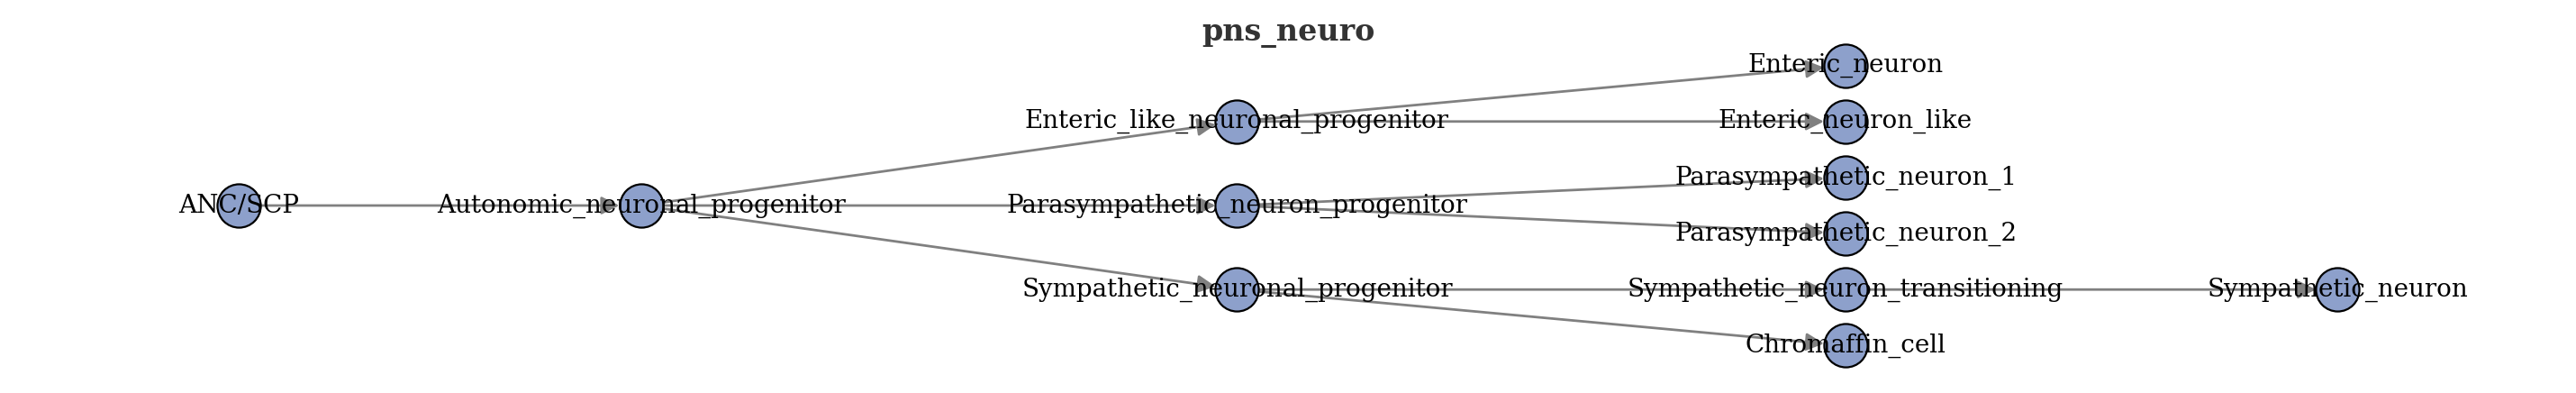

[]

In [25]:
trajectory = "pns_neuro"
_input_trajectory = InputTrajectories(ground_truth_trajectories).get_trajectory(trajectory, include_additional_nodes=True)
_input_trajectory.plot_trajectory(
    title=trajectory,
    figsize=(15, 2), 
    label_offset=0,
)
un = np.unique(out_df[ground_truth_trajectories_annotation_level[trajectory]])
[n for n in _input_trajectory.nodes() if n not in un]

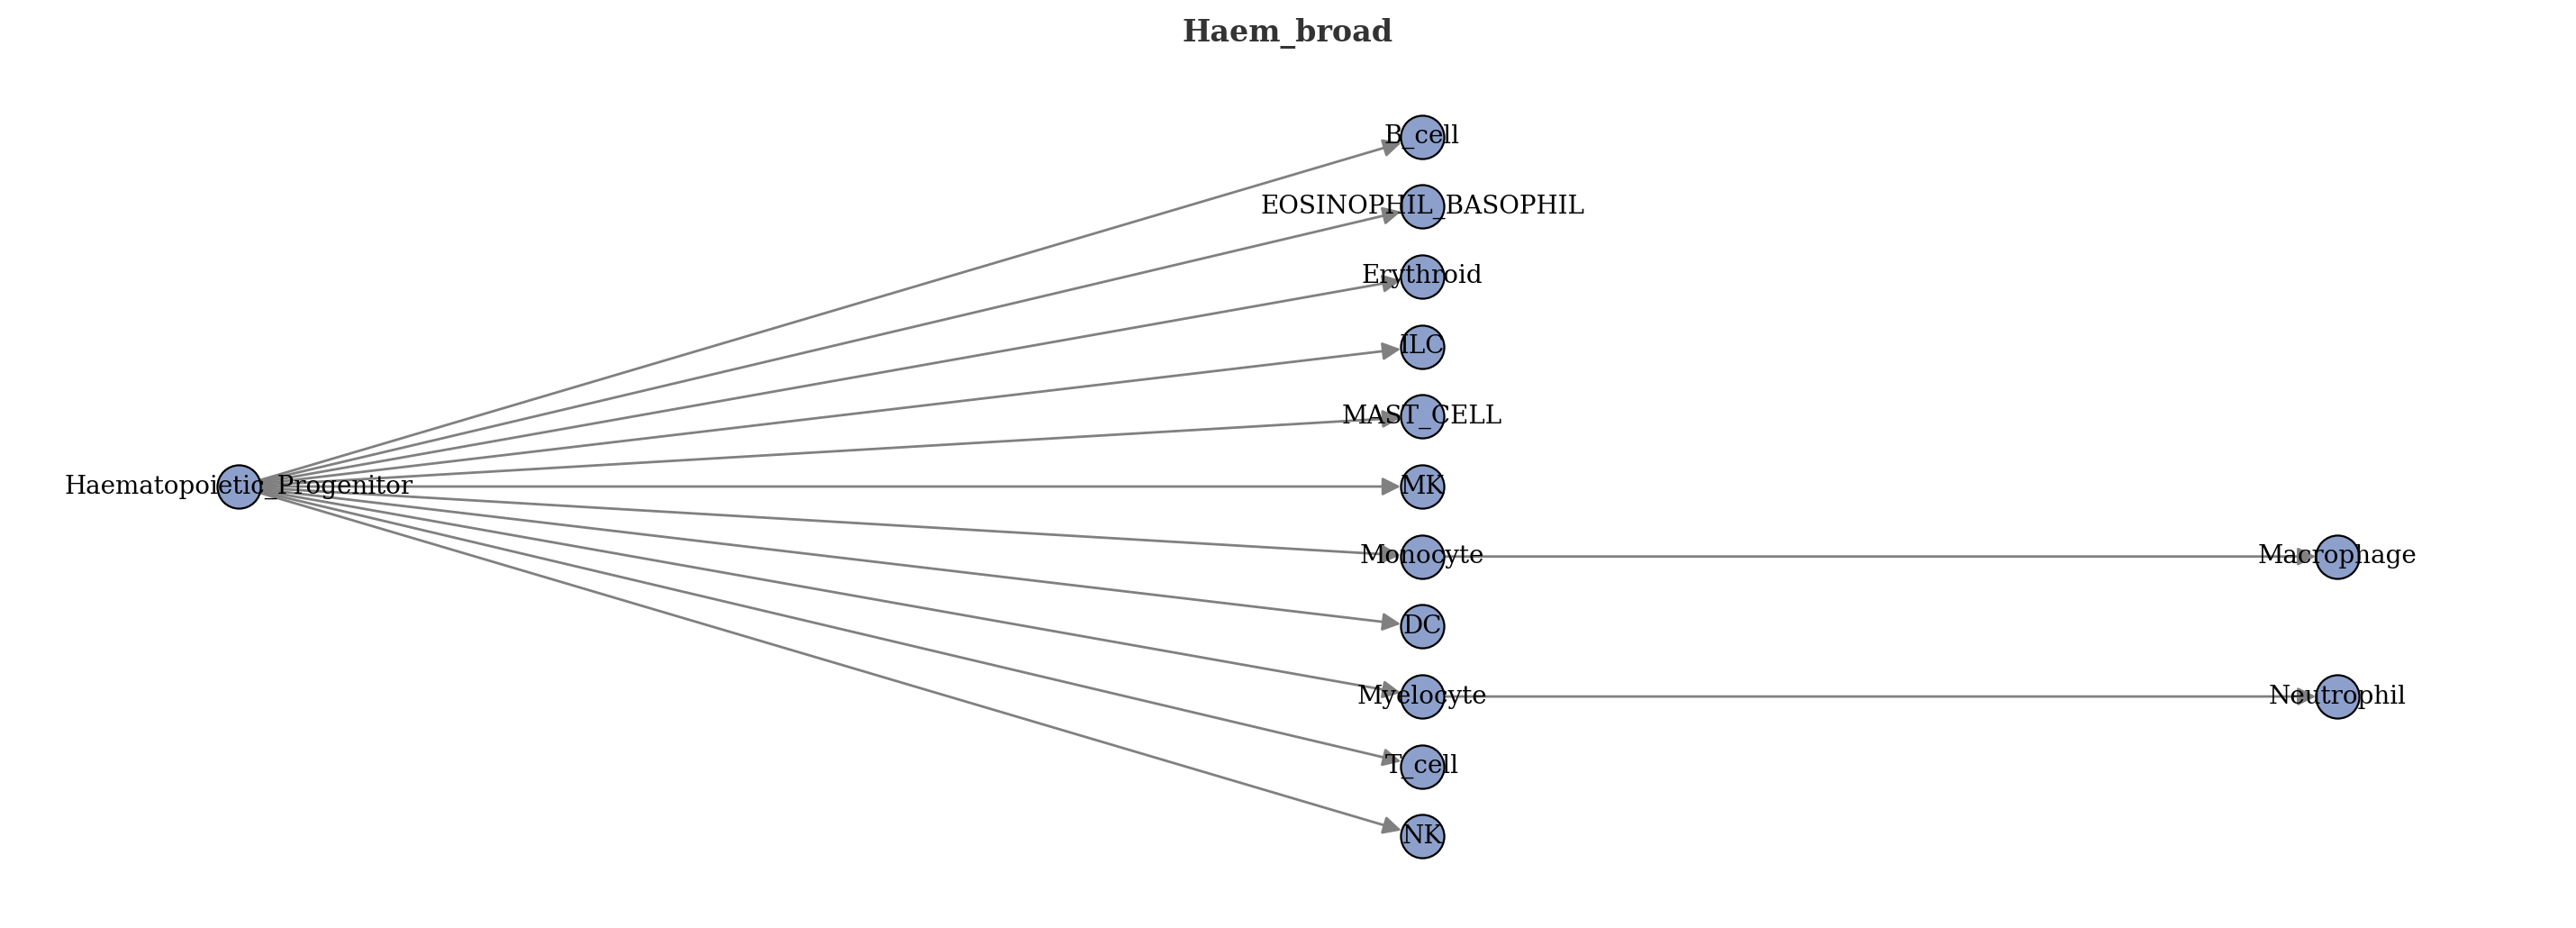

[]

In [26]:
trajectory = "Haem_broad"
_input_trajectory = InputTrajectories(ground_truth_trajectories).get_trajectory(trajectory, include_additional_nodes=True)
_input_trajectory.plot_trajectory(
    title=trajectory,
    figsize=(15, 5), 
    label_offset=0,
)
un = np.unique(out_df[ground_truth_trajectories_annotation_level[trajectory]])
[n for n in _input_trajectory.nodes() if n not in un]

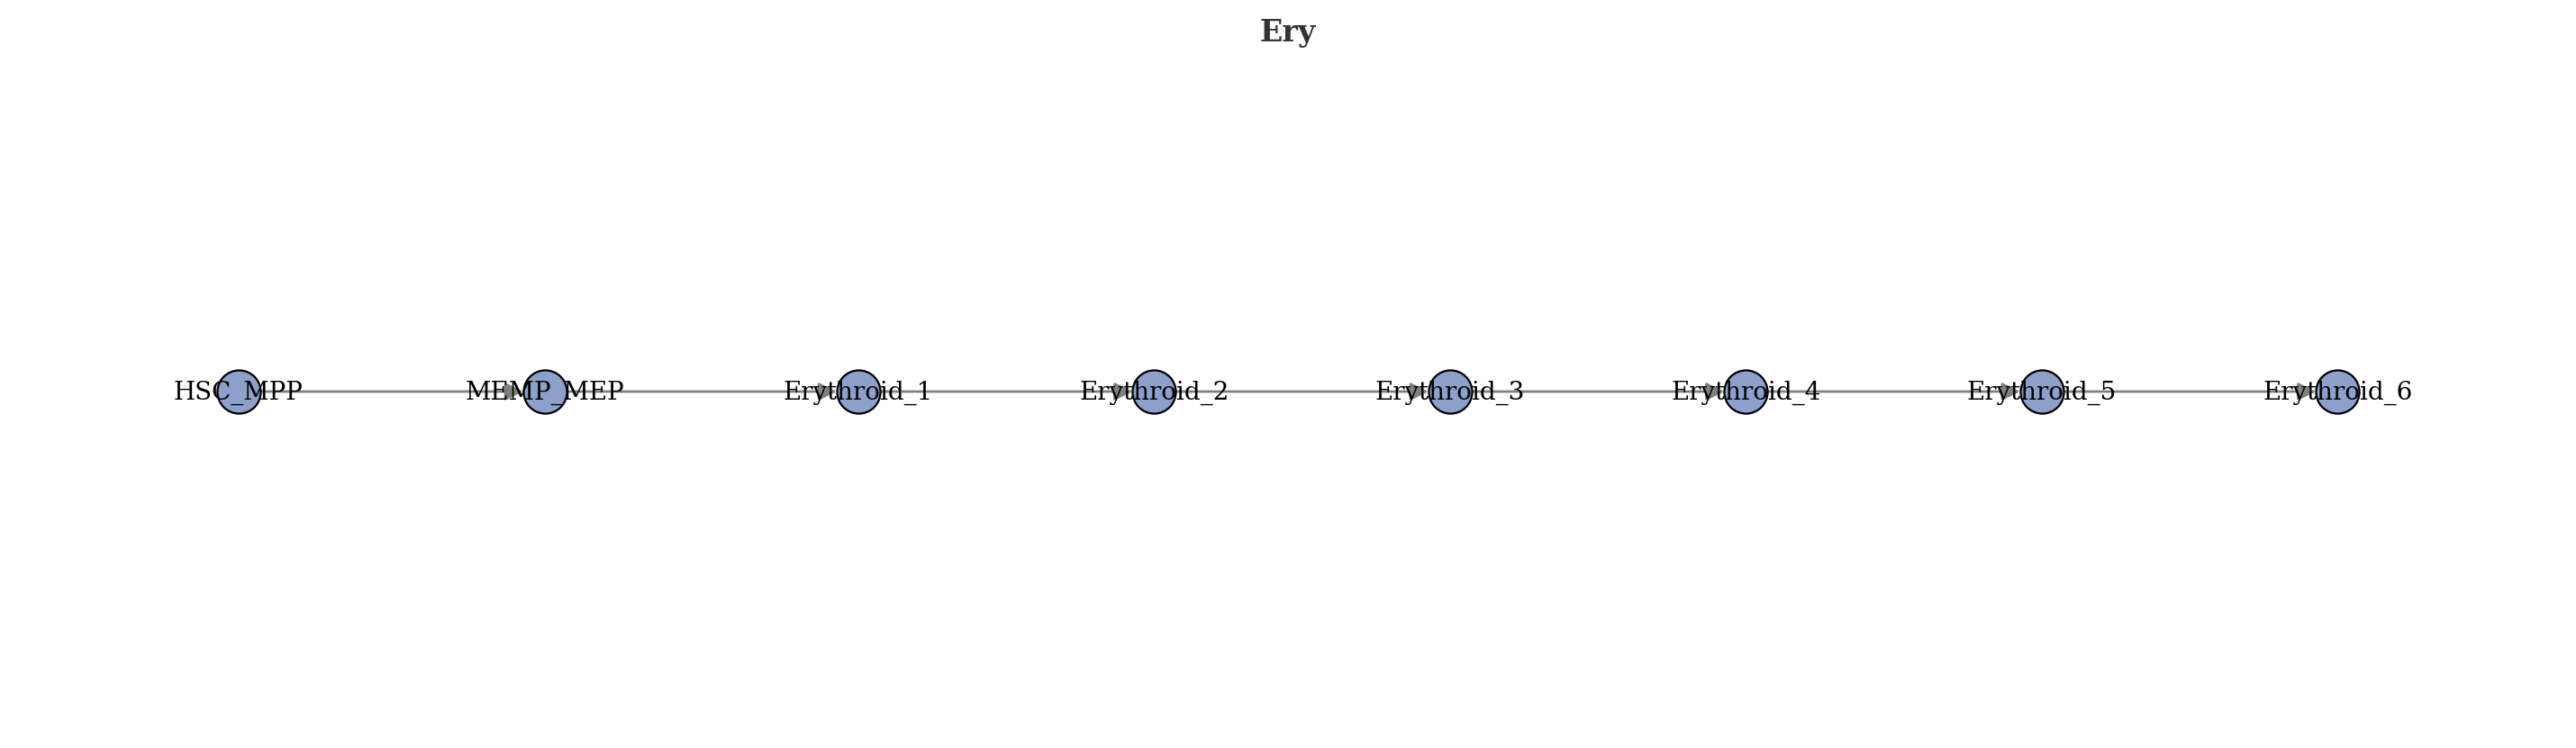

[]

In [27]:
trajectory = "Ery"
_input_trajectory = InputTrajectories(ground_truth_trajectories).get_trajectory(trajectory, include_additional_nodes=True)
_input_trajectory.plot_trajectory(
    title=trajectory,
    figsize=(15, 4), 
    label_offset=0,
)
un = np.unique(out_df[ground_truth_trajectories_annotation_level[trajectory]])
[n for n in _input_trajectory.nodes() if n not in un]

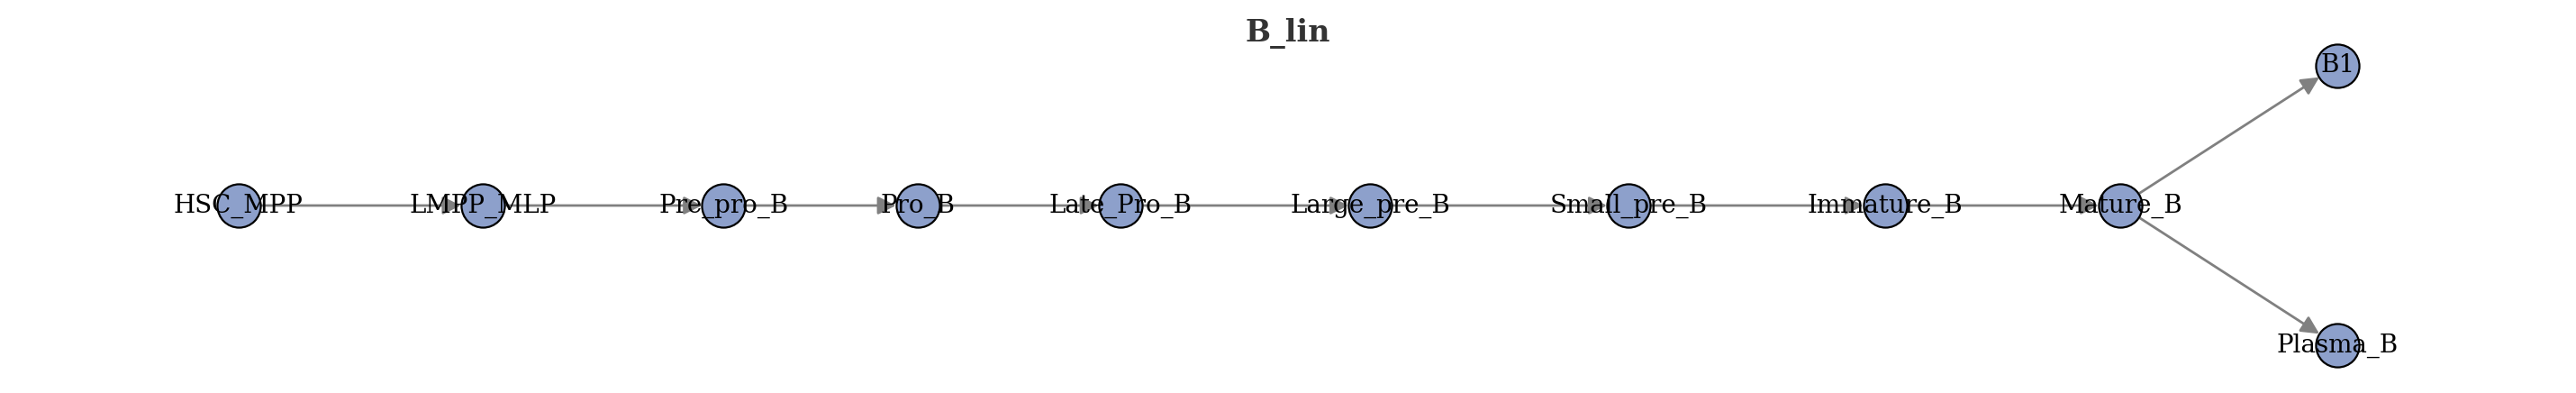

[]

In [28]:
trajectory = "B_lin"
_input_trajectory = InputTrajectories(ground_truth_trajectories).get_trajectory(trajectory, include_additional_nodes=True)
_input_trajectory.plot_trajectory(
    title=trajectory,
    figsize=(15, 2), 
    label_offset=0,
)
un = np.unique(out_df[ground_truth_trajectories_annotation_level[trajectory]])
[n for n in _input_trajectory.nodes() if n not in un]

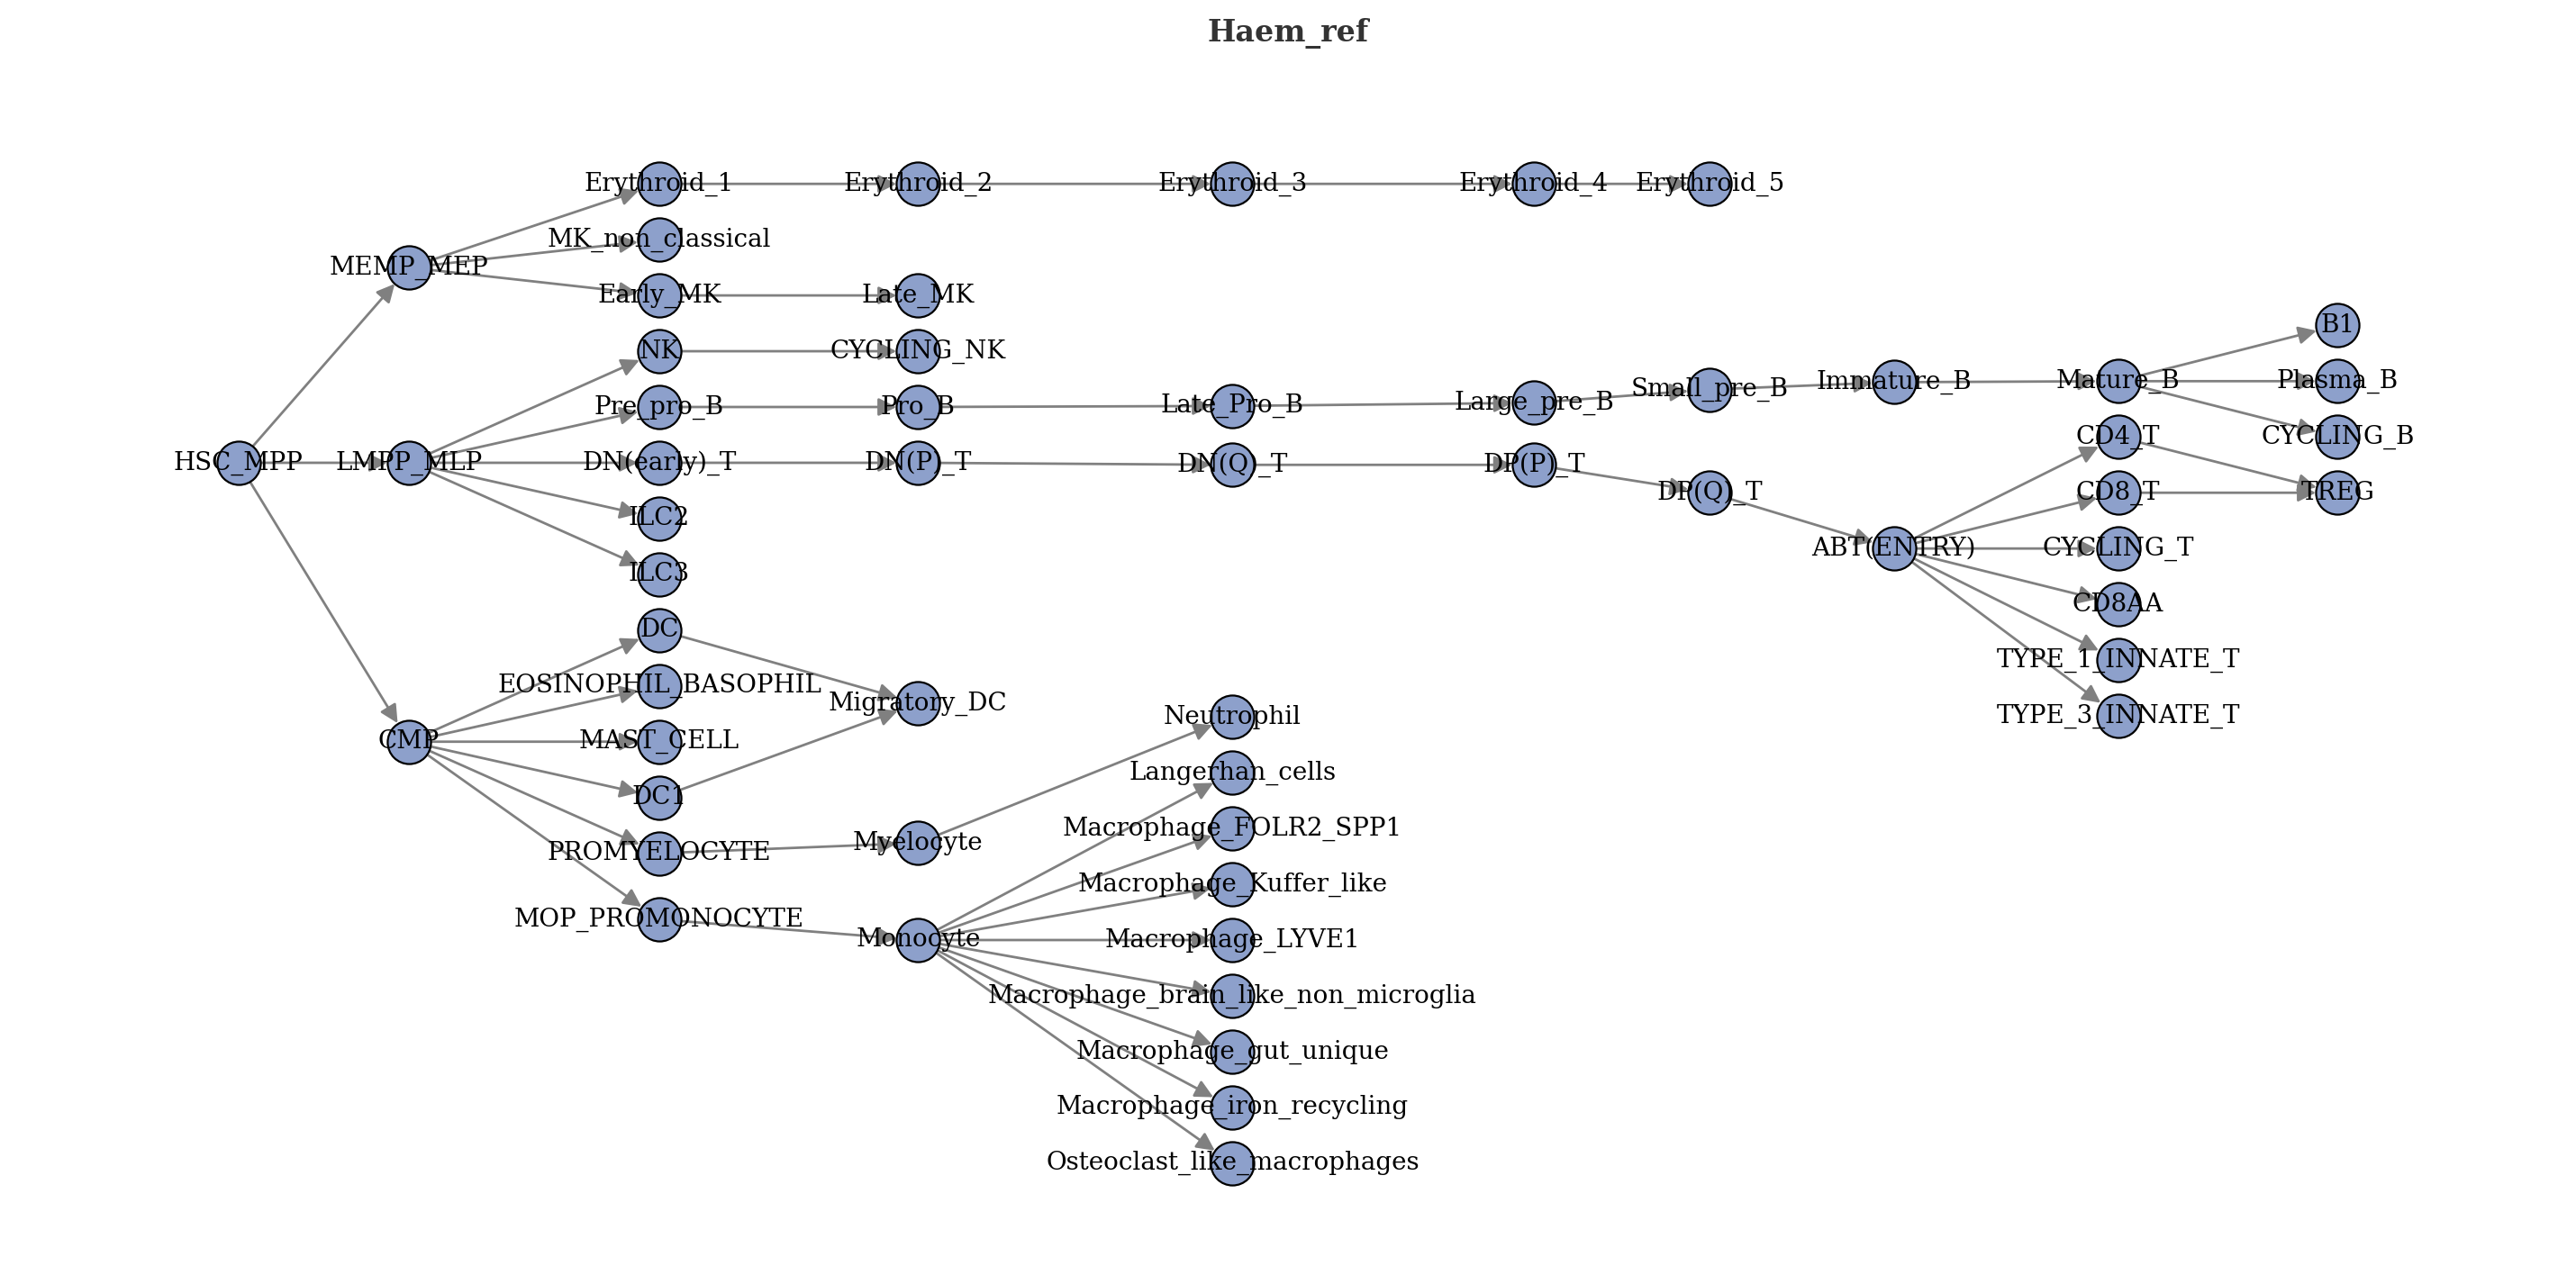

[]

In [29]:
trajectory = "Haem_ref"
_input_trajectory = InputTrajectories(ground_truth_trajectories).get_trajectory(trajectory, include_additional_nodes=True)
_input_trajectory.plot_trajectory(
    title=trajectory,
    figsize=(15, 7), 
    label_offset=0,
)
un = np.unique(out_df[ground_truth_trajectories_annotation_level[trajectory]])
[n for n in _input_trajectory.nodes() if n not in un]

In [30]:
ground_truth_trajectories_annotation_level

{'germline': 'ref_anno2',
 'pns_neuro': 'ref_anno2',
 'pns_glia': 'ref_anno1',
 'Haem_broad': 'broad_anno',
 'Ery': 'ref_anno1',
 'B_lin': 'ref_anno1',
 'Haem_ref': 'ref_anno1'}

In [31]:
for trajectory in ground_truth_trajectories:
    _input_trajectory = InputTrajectories(ground_truth_trajectories).get_trajectory(trajectory, include_additional_nodes=True)
    _input_trajectory_len = len(list(_input_trajectory.nodes()))
    print(f"{trajectory!r} = {_input_trajectory_len!r}")

'germline' = 8
'pns_neuro' = 12
'pns_glia' = 8
'Haem_broad' = 14
'Ery' = 8
'B_lin' = 11
'Haem_ref' = 57


## Subsetting and calculating kNN

In [32]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(out_df.value_counts(["LVL0"]))

LVL0                  
Neuronal_and_Glial        1716021
Stromal                    995174
Haematopoeitic_lineage     646830
Epithelial                 125451
Endothelial                 97794
Germline_lineage            10993
Lateral_plate_mesoderm      10138
Neural_crest                 6831
Notochord                      33
Name: count, dtype: int64

In [33]:
# trajectory = "pns_neuro"
# annotation_level = ground_truth_trajectories_annotation_level[trajectory]
# _input_trajectory = InputTrajectories(ground_truth_trajectories).get_trajectory(trajectory, include_additional_nodes=True)
# df = out_df[out_df[annotation_level].isin(_input_trajectory.nodes())]

In [34]:
trajectory_subset_dict = {
    "B_lin": ("LVL0", "Haematopoeitic_lineage", 0.5),
    "Ery": ("LVL0", "Haematopoeitic_lineage", 0.5),
    "germline": ("LVL0", "Germline_lineage", 1.0),
    "Haem_broad": ("LVL0", "Haematopoeitic_lineage", 0.5),
    "Haem_ref": ("LVL0", "Haematopoeitic_lineage", 0.5),
    "pns_glia": ("LVL0", "Neuronal_and_Glial", 0.2),
    "pns_neuro": ("LVL0", "Neuronal_and_Glial", 0.2),
}

In [35]:
tardis_save_path = "/lustre/groups/ml01/workspace/kemal.inecik/hdca/temp/preprocessing/tardis_dict.pkl"
with open(tardis_save_path, "rb") as f:
    df_hdca_lvl3_adata_paths["tardis"] = pickle.load(f)

In [36]:
df_hdca_lvl3_adata_paths["scanoroma"] = {
    "latent": "/lustre/groups/ml01/workspace/kemal.inecik/hdca/temp/preprocessing/unification_union_20240330_hvg-intersection_integration_X_scanorama.h5ad",
    "dataset": df_hdca_lvl3_adata_paths["scvi"]["dataset"]
}

## Save objects

In [37]:
# Saving the objects to be used in the scripts
pickle_bundle_path = os.path.join(dataset_dir, "_experiment_development_atlas_helper_pickle_bundle.pkl")
pickle_bundle = (
    df_hdca_component_adata_paths,
    df_hdca_lvl3_adata_paths,
    out_df,
    ground_truth_trajectories,
    ground_truth_trajectories_annotation_level,
    trajectory_subset_dict
)
save_pickle_bundle(pickle_bundle_path, pickle_bundle)

## Running the scTRAM

In [38]:
pickle_bundle_path = os.path.join(dataset_dir, "_experiment_development_atlas_helper_pickle_bundle.pkl")
(
    df_hdca_component_adata_paths,
    df_hdca_lvl3_adata_paths,
    out_df,
    ground_truth_trajectories,
    ground_truth_trajectories_annotation_level,
    trajectory_subset_dict
) = load_pickle_bundle(pickle_bundle_path)

In [39]:
df_hdca_lvl3_adata_paths.keys()

dict_keys(['scvi', 'scpoli', 'harmony', 'pca', 'tardis', 'scanoroma'])

In [40]:
override = False

count = 0
run_id = "fig2base"
warning_already_exist = []
for trajectory, trajectory_annotation_column in ground_truth_trajectories_annotation_level.items():

    memory_needed = 300
    
    for use_rep in df_hdca_lvl3_adata_paths:

        base_job_name = f"{run_id}_c1_{trajectory}_c2_{use_rep}"
        output_file_path = os.path.join(dataset_dir, f"metric_sctram_{base_job_name}.pkl")
        log_file = os.path.join(logs_directory, f"slurm_out_metric_sctram_{base_job_name}.log")
        slurmjob_name = base_job_name

        if override or not os.path.exists(output_file_path) or not os.path.isfile(output_file_path):
            try:
                slurm_script = f"""#!/bin/bash
#SBATCH -J {slurmjob_name}
#SBATCH -p cpu_p
#SBATCH --qos cpu_normal
#SBATCH -c 4
#SBATCH --mem={memory_needed}G
#SBATCH --nice=0
#SBATCH -t 6:00:00
#SBATCH -o {log_file}
#SBATCH -e {log_file}

source activate sctram_dev_env
python -u {os.path.join(helpers_directory, 'sctram_runner.py')} --run_id "{run_id}" --trajectory "{trajectory}" --use_rep "{use_rep}" --trajectory_annotation_column "{trajectory_annotation_column}" 
"""
                slurm_script_name = os.path.join(logs_directory, f"slurm_job_metric_sctram_{base_job_name}.sh")
                with open(slurm_script_name, "w") as _file_slurm_script:
                    _file_slurm_script.write(slurm_script)

                print(f"Submitted job: {base_job_name!r}")
                subprocess.run(["sbatch", slurm_script_name])
                count += 1
                # if count > 2:
                #     raise ValueError
            finally:
                time.sleep(0.05)
                os.remove(slurm_script_name)
        else:
            print(f"Already exist: {base_job_name!r}")
            warning_already_exist.append(base_job_name)

print(f" - Number of jobs submitted: {count}")

Already exist: 'fig2base_c1_germline_c2_scvi'
Already exist: 'fig2base_c1_germline_c2_scpoli'
Already exist: 'fig2base_c1_germline_c2_harmony'
Already exist: 'fig2base_c1_germline_c2_pca'
Already exist: 'fig2base_c1_germline_c2_tardis'
Already exist: 'fig2base_c1_germline_c2_scanoroma'
Already exist: 'fig2base_c1_pns_neuro_c2_scvi'
Already exist: 'fig2base_c1_pns_neuro_c2_scpoli'
Already exist: 'fig2base_c1_pns_neuro_c2_harmony'
Already exist: 'fig2base_c1_pns_neuro_c2_pca'
Already exist: 'fig2base_c1_pns_neuro_c2_tardis'
Already exist: 'fig2base_c1_pns_neuro_c2_scanoroma'
Already exist: 'fig2base_c1_pns_glia_c2_scvi'
Already exist: 'fig2base_c1_pns_glia_c2_scpoli'
Already exist: 'fig2base_c1_pns_glia_c2_harmony'
Already exist: 'fig2base_c1_pns_glia_c2_pca'
Already exist: 'fig2base_c1_pns_glia_c2_tardis'
Already exist: 'fig2base_c1_pns_glia_c2_scanoroma'
Already exist: 'fig2base_c1_Haem_broad_c2_scvi'
Already exist: 'fig2base_c1_Haem_broad_c2_scpoli'
Already exist: 'fig2base_c1_Haem_br

# Collect and plot

In [41]:
result_df = pd.DataFrame()
run_id = "fig2base"
for trajectory, trajectory_annotation_column in ground_truth_trajectories_annotation_level.items():
    
    for use_rep in df_hdca_lvl3_adata_paths:

        base_job_name = f"{run_id}_c1_{trajectory}_c2_{use_rep}"
        output_file_path = os.path.join(dataset_dir, f"metric_sctram_{base_job_name}.pkl")
        
        if not os.path.exists(output_file_path) or not os.path.isfile(output_file_path):
            print("not yet there:", base_job_name)
            
        else:
            df_trajectory_obsm = pd.read_pickle(output_file_path)
            df_trajectory_obsm["representation"] = use_rep
            df_trajectory_obsm["trajectory"] = trajectory
            df_trajectory_obsm["trajectory_annotation_column"] = trajectory_annotation_column
            result_df = pd.concat([result_df, df_trajectory_obsm])

result_df.reset_index(drop=True, inplace=True)
result_df['score'] = pd.to_numeric(result_df['score'], errors='raise')
trajectory_label_mapping = {
    "B_lin": "Hematopoietic Lineage",
    "Ery": "Hematopoietic Lineage",
    "Haem_broad": "Hematopoietic Lineage",
    "Haem_ref": "Hematopoietic Lineage",
    "pns_glia": "Peripheral Nervous System",
    "pns_neuro": "Peripheral Nervous System",
    "germline": "Germline"
}
result_df["trajectory_class"] = pd.Series([trajectory_label_mapping[i] for i in result_df["trajectory"]])
column_to_sort = ["trajectory_class", "trajectory", "path", "metric", "representation", "trajectory_annotation_column", "score"]
result_df.sort_values(by=column_to_sort, inplace=True, ignore_index=True)
result_df = result_df[column_to_sort]

In [42]:
def rank_metrics(df, metric_direction_dict, metric_index_pos, method='min'):
    ranked_df = pd.DataFrame(index=df.index, columns=df.columns, dtype=float)
    for indices, row in df.iterrows():
        
        metric = indices[metric_index_pos]
        direction = metric_direction_dict.get(metric)
        
        if direction not in ('increasing', 'decreasing'):
            raise ValueError            
        
        numeric_row = pd.to_numeric(row, errors='coerce')
        if numeric_row.isna().any():
            ranked_df.loc[indices] = np.nan
            continue
        
        if direction == 'increasing':
            ranks = numeric_row.rank(method='dense', ascending=False)
        else:
            ranks = numeric_row.rank(method='dense', ascending=True)

        # ranks = 1 - pd.Series(MinMaxScaler().fit_transform(row.values.reshape(-1, 1)).flatten(), index=row.index)
        
        ranked_df.loc[indices] = ranks.astype('Float64')
    return ranked_df

In [58]:
result_df.to_pickle(os.path.join(dataset_dir, "_experiment_development_atlas_result_df_dataframe.pkl"))

In [43]:
df_pivot = result_df.pivot(index=["trajectory_class", 'trajectory', 'path', 'metric'], columns='representation', values='score')
df_pivot_rank = rank_metrics(df_pivot, metric_direction_dict, metric_index_pos=3, method='min')
df_pivot_rank

representation                                                                    harmony  \
trajectory_class          trajectory path       metric                                      
Germline                  germline   adjacency  accuracy                              2.0   
                                                average_shortest_path_difference      2.0   
                                                clustering_coeff_diff                 5.0   
                                                f1_score                              3.0   
                                                frobenius                             5.0   
...                                                                                   ...   
Peripheral Nervous System pns_neuro  pseudotime pearson_correlation                   4.0   
                                                r_squared                             6.0   
                                                r_squared_with_spline                 4.0   
                                                spearman_correlation                  5.0   
                                                wasserstein_distance_pseudotime       6.0   

representation                                                                    pca  \
trajectory_class          trajectory path       metric                                  
Germline                  germline   adjacency  accuracy                          2.0   
                                                average_shortest_path_difference  3.0   
                                                clustering_coeff_diff             4.0   
                                                f1_score                          3.0   
                                                frobenius                         4.0   
...                                                                               ...   
Peripheral Nervous System pns_neuro  pseudotime pearson_correlation               5.0   
                                                r_squared                         3.0   
                                                r_squared_with_spline             5.0   
                                                spearman_correlation              4.0   
                                                wasserstein_distance_pseudotime   2.0   

representation                                                                    scanoroma  \
trajectory_class          trajectory path       metric                                        
Germline                  germline   adjacency  accuracy                                3.0   
                                                average_shortest_path_difference        1.0   
                                                clustering_coeff_diff                   6.0   
                                                f1_score                                4.0   
                                                frobenius                               6.0   
...                                                                                     ...   
Peripheral Nervous System pns_neuro  pseudotime pearson_correlation                     6.0   
                                                r_squared                               5.0   
                                                r_squared_with_spline                   6.0   
                                                spearman_correlation                    6.0   
                                                wasserstein_distance_pseudotime         4.0   

representation                                                                    scpoli  \
trajectory_class          trajectory path       metric                                     
Germline                  germline   adjacency  accuracy                             1.0   
                                                average_shortest_path_difference     5.0   
                            

In [44]:
df_pivot_rank_mean = df_pivot_rank.groupby(level=1).mean()
display(df_pivot_rank_mean)
display(df_pivot_rank_mean.mean())

representation,harmony,pca,scanoroma,scpoli,scvi,tardis
trajectory,,,,,,
B_lin,4.613636,3.250000,5.000000,2.704545,2.022727,3.181818
Ery,4.131579,2.526316,3.736842,2.894737,3.368421,2.500000
Haem_broad,4.181818,2.863636,4.113636,3.045455,2.250000,3.431818
Haem_ref,4.418605,2.279070,4.581395,3.255814,1.953488,4.418605
germline,3.925000,3.350000,4.725000,2.475000,2.050000,2.325000
pns_glia,4.363636,3.636364,4.568182,2.431818,2.136364,3.295455
pns_neuro,5.045455,3.159091,3.522727,2.568182,2.840909,3.636364


representation
harmony      4.382818
pca          3.009211
scanoroma    4.321112
scpoli       2.767936
scvi         2.374558
tardis       3.255580
dtype: float64

In [45]:
rename_model_name_dict = {
    'pca': 'PCA',
    'X_pca': 'PCA',
    'harmony': 'Harmony',
    'invae': 'inVAE',
    'scanvi': 'scANVI',
    'scvi': 'scVI',
    'scpoli': 'scPoli',
    'scanoroma': 'Scanoroma',
    'tardis_1': 'DELETE ME',
    'tardis_2': 'TarDis',
    'tardis': 'TarDis',
}
col_order = ['Scanoroma', 'Harmony', 'TarDis', 'PCA', 'scPoli', 'scVI']

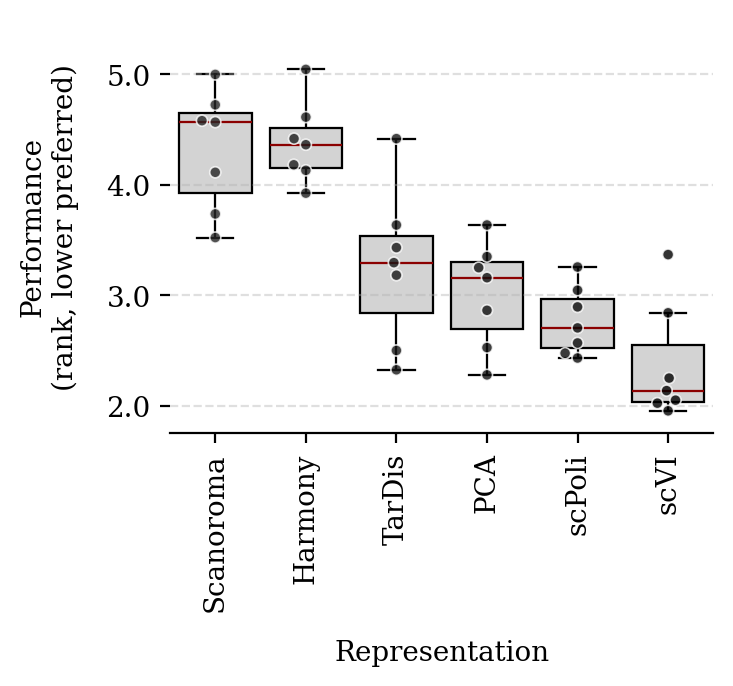

In [46]:
def _(df):
    df = df.rename(columns=rename_model_name_dict)
    df = df[col_order]
    
    fig_height=4
    n_cols = df.shape[1]
    col_width = 0.7  # Width per column in inches
    fig_width = n_cols * col_width
    # fig_height = 8  # Fixed height for better vertical readability
    
    # Create figure with dynamic width
    plt.figure(figsize=(fig_width, fig_height))
    
    # Create boxplot with refined styling
    bp = sns.boxplot(data=df,
                     width=0.8,
                     showfliers=False,
                     boxprops=dict(facecolor='lightgray', edgecolor='black', linewidth=0.81),
                     whiskerprops=dict(color='black', linewidth=0.81),
                     medianprops=dict(color='darkred', linewidth=0.81),
                     capprops=dict(color='black', linewidth=0.81),
                     saturation=1,
                     zorder=1)
    
    # Add swarmplot with sophisticated aesthetics
    sp = sns.swarmplot(data=df,
                       size=4,
                       palette='dark:black',
                       edgecolor='white',
                       linewidth=0.6,
                       alpha=0.8,
                       marker='o',
                       zorder=2)
    
    # Enhance axis styling
    plt.xticks(rotation=90, ha='center', fontsize=10)
    plt.yticks(fontsize=10)
    plt.xlabel('Representation', fontsize=10, labelpad=10)
    plt.ylabel("Performance\n(rank, lower preferred)", fontsize=10, labelpad=10)
    
    plt.gca().set_ylim(1.75, 5.5)
    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    
    # Add light grid and adjust borders
    bp.grid(axis='y', linestyle='--', alpha=0.4)
    sns.despine(left=True, trim=False)
    
    # Adjust layout with professional spacing
    plt.tight_layout(rect=[0.05, 0.05, 0.95, 0.95])
    plt.show()
_(df_pivot_rank_mean)

In [47]:
df_pivot_rank_mean = df_pivot_rank.groupby(level=[0, 1]).mean()
df_pivot_rank_mean = df_pivot_rank_mean.rename(columns=rename_model_name_dict)
df_pivot_rank_mean = df_pivot_rank_mean[col_order]
df_long = df_pivot_rank_mean.reset_index().melt(id_vars=['trajectory_class', 'trajectory'], var_name='representation', value_name='score')

/tmp/ipykernel_1290869/2456694223.py:11: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  bp = sns.barplot(
/tmp/ipykernel_1290869/2456694223.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', fontsize=10)


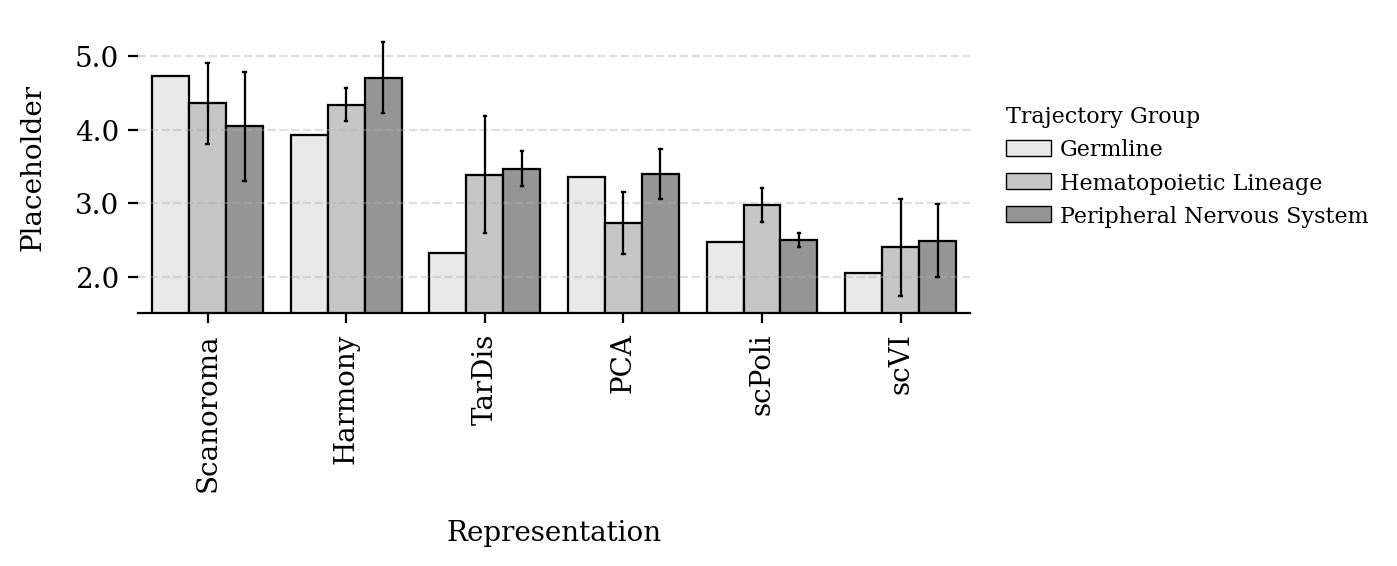

In [48]:
# match boxplot’s height & per-column width
fig_height = 3
n_cols = df_long["representation"].nunique()
col_width = 1.4
fig_width = n_cols * col_width
n_tc = len(np.unique(df_long["trajectory_class"]))

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

# draw bars
bp = sns.barplot(
    data=df_long,
    x="representation",
    y="score",
    hue="trajectory_class",
    palette=sns.color_palette("Greys", n_colors=n_tc+2),
    width=0.8,
    saturation=1,
    errorbar="sd",
    capsize=0.05,
    err_kws={'color': 'black', 'linewidth': 0.81},
    edgecolor="black",
    linewidth=0.81,
    zorder=1,
    ax=ax
)

# enforce edge styling
for patch in bp.patches:
    patch.set_edgecolor("black")
    patch.set_linewidth(0.81)

# axes
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', fontsize=10)
ax.tick_params(axis="y", labelsize=10)
ax.set_xlabel('Representation', fontsize=10, labelpad=10)
ax.set_ylabel('Placeholder', fontsize=10, labelpad=10)

ax.set_ylim(1.5, 5.5)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

# grid + despine
ax.grid(axis='y', linestyle='--', alpha=0.4)
sns.despine(left=True, trim=False)

# remove the old legend
ax.legend_.remove()

# build new, professional legend
handles, labels = ax.get_legend_handles_labels()

slim_handles = [
    mpatches.Patch(
        facecolor=h.get_facecolor(),   # <-- keep the whole RGBA tuple
        edgecolor="black",
        linewidth=0.5                  #   thinner border
    )
    for h in handles
]

leg = ax.legend(
    slim_handles,
    labels,
    title="Trajectory Group",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    alignment="left",
    title_fontsize=8,
    fontsize=8,
    borderaxespad=0.5,
    handletextpad=0.4,
    labelspacing=0.5,
)

# tighten layout (accounts for legend)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


In [49]:
df_pivot_rank_mean = df_pivot_rank.groupby(level=[2, 1]).mean()
df_pivot_rank_mean = df_pivot_rank_mean.rename(columns=rename_model_name_dict)
df_pivot_rank_mean = df_pivot_rank_mean[col_order]
df_long = df_pivot_rank_mean.reset_index().melt(id_vars=['path', 'trajectory'], var_name='representation', value_name='score')

/tmp/ipykernel_1290869/3121055197.py:16: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  bp = sns.barplot(
/tmp/ipykernel_1290869/3121055197.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', fontsize=10)


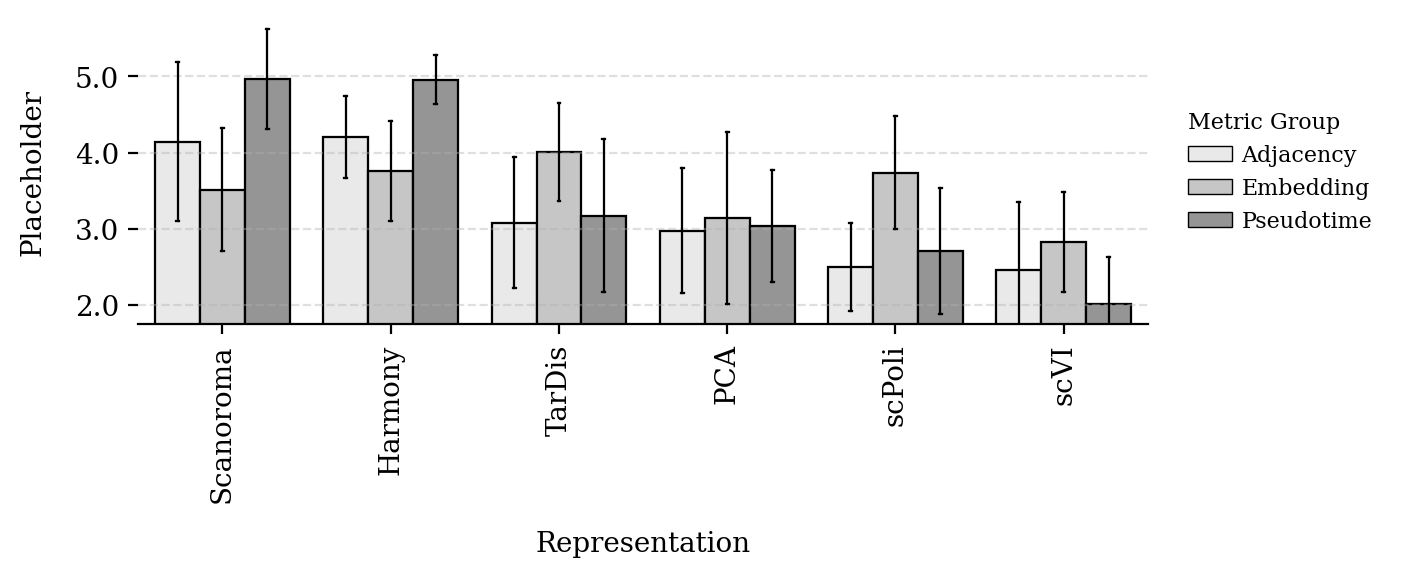

In [50]:
label_mapping = {
    "adjacency": "Adjacency",
    "embedding": "Embedding",
    "pseudotime": "Pseudotime",
}

# match boxplot’s height & per-column width
fig_height = 3
n_cols = df_long["representation"].nunique()
col_width = 1.4
fig_width = n_cols * col_width

fig, ax = plt.subplots(figsize=(fig_width, fig_height))

# draw bars
bp = sns.barplot(
    data=df_long,
    x="representation",
    y="score",
    hue="path",
    palette=sns.color_palette("Greys", n_colors=len(label_mapping)+2),
    width=0.8,
    saturation=1,
    errorbar="sd",
    capsize=0.05,
    err_kws={'color': 'black', 'linewidth': 0.81},
    edgecolor="black",
    linewidth=0.81,
    zorder=1,
    ax=ax
)

# enforce edge styling
for patch in bp.patches:
    patch.set_edgecolor("black")
    patch.set_linewidth(0.81)

# axes
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', fontsize=10)
ax.tick_params(axis="y", labelsize=10)
ax.set_xlabel('Representation', fontsize=10, labelpad=10)
ax.set_ylabel('Placeholder', fontsize=10, labelpad=10)

ax.set_ylim(1.75, 5.75)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

# grid + despine
ax.grid(axis='y', linestyle='--', alpha=0.4)
sns.despine(left=True, trim=False)

# remove the old legend
ax.legend_.remove()

# build new, professional legend
handles, labels = ax.get_legend_handles_labels()
new_labels = [label_mapping.get(l, l) for l in labels]

slim_handles = [
    mpatches.Patch(
        facecolor=h.get_facecolor(),   # <-- keep the whole RGBA tuple
        edgecolor="black",
        linewidth=0.5                  #   thinner border
    )
    for h in handles
]

leg = ax.legend(
    slim_handles,
    new_labels,
    title="Metric Group",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    alignment="left",
    frameon=False,
    title_fontsize=8,
    fontsize=8,
    borderaxespad=0.5,
    handletextpad=0.4,
    labelspacing=0.5,
)

# tighten layout (accounts for legend)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


# Table with scIB

In [51]:
trained_runs_path_benchmarked = "/lustre/groups/ml01/workspace/kemal.inecik/hdca/temp/models/trained_models_benchmarked.pickle"
with open(trained_runs_path_benchmarked, 'rb') as file:
    arguments, runs_df = pickle.load(file)

scvi_runs = "/home/icb/kemal.inecik/work/codes/hdca/integration/4.0_training/scvi/trained_hypers.db"
scpoli_runs = "/home/icb/kemal.inecik/work/codes/hdca/integration/4.0_training/scpoli/trained_hypers.db"
with sqlite3.connect(scvi_runs) as conn:
    trained_scvi = pd.read_sql_query("SELECT * FROM data", conn)
with sqlite3.connect(scpoli_runs) as conn:
    trained_scpoli = pd.read_sql_query("SELECT * FROM data", conn)

dataset_dict = {
    '/lustre/groups/ml01/workspace/kemal.inecik/hdca/temp/preprocessing/unification_union_20240330_hvg_integration.h5ad': "union",
    '/lustre/groups/ml01/workspace/kemal.inecik/hdca/temp/preprocessing/unification_union_20240330_hvg-intersection_integration.h5ad': "intersection",
}

_run_df = []
for ind, run in runs_df.iterrows():
    if run["model"] in ["pca", "harmony", "tardis", "scanoroma"]:
        run["n_epochs_kl_warmup"] = np.nan
        run["batch_strategy"] = "concatenate"
        run["dataset_strategy"] = dataset_dict[item["dataset"].item()]
    elif run["model"] == "scvi":
        item = trained_scvi[trained_scvi["experiment_id"] == run["name"]]
        assert len(item) == 1
        run["n_epochs_kl_warmup"] = item["n_epochs_kl_warmup"].item()
        run["batch_strategy"] = item["batch_strategy"].item()
    elif run["model"] == "scpoli":
        item = trained_scpoli[trained_scpoli["experiment_id"] == run["name"]]
        assert len(item) == 1
        run["n_epochs_kl_warmup"] = item["n_epochs_kl_warmup"].item()
        run["batch_strategy"] = item["batch_strategy"].item()
    
    else:
        raise ValueError
    
    run["dataset_strategy"] = dataset_dict[run["dataset"]]
    for label_key_level in ["LVL2", "LVL3"]:
        run["label_key"] = label_key_level
        _run_df.append(run.copy())

__run_df = []
for run in _run_df:
    pickle_path_bio = os.path.join("/home/icb/kemal.inecik/lustre_workspace/hdca/temp/scib/20240619", f"{run['name']}_bio_{run['label_key']}.pickle")
    pickle_path_batch = os.path.join("/home/icb/kemal.inecik/lustre_workspace/hdca/temp/scib/20240619", f"{run['name']}_batch_{run['label_key']}.pickle")    
    metrics_bio = pd.read_pickle(pickle_path_bio).loc["model"]
    metrics_batch = pd.read_pickle(pickle_path_batch).loc["model"]
    __run_df.append(pd.concat([run, metrics_bio, metrics_batch]))
df = pd.DataFrame(__run_df)
df["Total scIB"] = df["Bio conservation"] * 0.6 + df["Batch correction"] * 0.4

df_lvl2 = df[df["label_key"] == "LVL2"]
df_lvl3 = df[df["label_key"] == "LVL3"]

columns_to_keep = [
    'model', 'isolated_labels',
    'nmi_ari_cluster_labels_kmeans_nmi',
    'nmi_ari_cluster_labels_kmeans_ari', 'silhouette_label', 'clisi_knn',
    'silhouette_batch', 'ilisi_knn', 'kbet_per_label',
    'graph_connectivity', 'pcr_comparison', 'Bio conservation', 'Batch correction', 'Total scIB'
]
model_order = ["pca", "tardis", "scanoroma", "harmony", "scpoli", "scvi"]

with pd.option_context('display.max_columns', None, 'display.max_rows', None): 
    _temp_df = df_lvl3.drop_duplicates(subset=["model"], keep='first')[columns_to_keep].copy()
    _temp_df.set_index("model", inplace=True)
    res_lvl3 = _temp_df.T[model_order]

with pd.option_context('display.max_columns', None, 'display.max_rows', None): 
    _temp_df = df_lvl2.drop_duplicates(subset=["model"], keep='first')[columns_to_keep].copy()
    _temp_df.set_index("model", inplace=True)
    res_lvl2 = _temp_df.T[model_order]

In [52]:
display(res_lvl2), display(res_lvl3);

model,pca,tardis,scanoroma,harmony,scpoli,scvi
isolated_labels,0.514707,0.519747,0.517413,0.479103,0.510967,0.569214
nmi_ari_cluster_labels_kmeans_nmi,0.635857,0.356923,0.625882,0.514720,0.285628,0.505130
nmi_ari_cluster_labels_kmeans_ari,0.168075,0.068586,0.161357,0.099449,0.047123,0.108795
silhouette_label,0.489092,0.468812,0.488696,0.436853,0.467842,0.448145
clisi_knn,0.999867,0.992301,0.999224,0.998808,0.983715,0.999234
silhouette_batch,0.842812,0.919865,0.846373,0.869394,0.921051,0.895734
ilisi_knn,0.006466,0.026198,0.011368,0.011664,0.036200,0.013167
kbet_per_label,0.337632,0.455056,0.382204,0.318889,0.503868,0.370166
graph_connectivity,0.794409,0.716632,0.414086,0.680950,0.595911,0.862005
pcr_comparison,0.000000,0.966497,0.094895,0.796611,0.976778,0.881101


model,pca,tardis,scanoroma,harmony,scpoli,scvi
isolated_labels,0.512291,0.480591,0.478103,0.476367,0.475747,0.471503
nmi_ari_cluster_labels_kmeans_nmi,0.658581,0.476386,0.608195,0.546803,0.376694,0.623989
nmi_ari_cluster_labels_kmeans_ari,0.160387,0.083411,0.123310,0.101341,0.053888,0.141534
silhouette_label,0.453129,0.467842,0.458069,0.422544,0.464812,0.458790
clisi_knn,0.998964,0.995196,0.997918,0.997810,0.991508,0.998331
silhouette_batch,0.844240,0.923115,0.852142,0.869164,0.929390,0.905006
ilisi_knn,0.006466,0.026198,0.011368,0.011664,0.036200,0.013167
kbet_per_label,0.372892,0.511627,0.394599,0.359290,0.523197,0.463950
graph_connectivity,0.656012,0.548250,0.262100,0.522266,0.407428,0.720219
pcr_comparison,0.000000,0.966497,0.094895,0.796611,0.976778,0.881101


In [57]:
res_lvl2.to_pickle(os.path.join(dataset_dir, "_experiment_development_atlas_res_lvl2_dataframe.pkl"))
res_lvl3.to_pickle(os.path.join(dataset_dir, "_experiment_development_atlas_res_lvl3_dataframe.pkl"))

In [53]:
sctram_summary = 1 / df_pivot_rank.groupby(level=[2, 3]).mean().groupby(level=0).mean()
_sctram_summary = 1 / pd.DataFrame(df_pivot_rank.groupby(level=3).mean().mean(), columns=["Total scTRAM"]).T
sctram_summary = pd.concat([sctram_summary, _sctram_summary], axis=0)
sctram_summary = sctram_summary.rename(
    index={"adjacency": "Adjacency-based", "embedding": "Embedding-based", "pseudotime": "Pseudotime-based"},
    columns=rename_model_name_dict,
)[col_order]
sctram_summary.index.name = None
sctram_summary.columns.name = "Representation"
sctram_summary

Representation,Scanoroma,Harmony,TarDis,PCA,scPoli,scVI
Adjacency-based,0.241379,0.237864,0.324503,0.335616,0.399457,0.407202
Embedding-based,0.278251,0.265343,0.251885,0.310389,0.271870,0.361357
Pseudotime-based,0.201729,0.201584,0.307523,0.339600,0.363873,0.496894
Total scTRAM,0.229799,0.226760,0.304428,0.332733,0.359799,0.426593


In [54]:
df_scib = res_lvl3
scib_summary = df_scib.loc[["Bio conservation", "Batch correction", "Total scIB"]]
scib_summary = scib_summary.rename(columns=rename_model_name_dict)[col_order]
scib_summary.index.name = None
scib_summary.columns.name = "Representation"
scib_summary

Representation,Scanoroma,Harmony,TarDis,PCA,scPoli,scVI
Bio conservation,0.533119,0.508973,0.500685,0.556670,0.472530,0.538829
Batch correction,0.323021,0.511799,0.595137,0.375922,0.574599,0.596689
Total scIB,0.449080,0.510104,0.538466,0.484371,0.513357,0.561973


In [61]:
sctram_summary.to_pickle(os.path.join(dataset_dir, "_experiment_development_atlas_sctram_summary_dataframe.pkl"))
scib_summary.to_pickle(os.path.join(dataset_dir, "_experiment_development_atlas_scib_summary_dataframe.pkl"))

In [55]:
summary = pd.concat([scib_summary, sctram_summary], keys=["scIB", "scTRAM"], axis=0)
summary.index.names = ["Source", "Metric Group"]
summary.columns.name = "Representation"
new_index_tuples = [
    ("Aggregate score", metric.split("Total ")[1]) if metric.startswith("Total ") else (src, metric) for src, metric in summary.index
]
summary.index = pd.MultiIndex.from_tuples(new_index_tuples, names=summary.index.names)

weights = {  # just provisional for now
    "scTRAM": 0.4,
    "scIB": 0.6,
}
row_ts = summary.loc[("Aggregate score", "scTRAM")]
row_si = summary.loc[("Aggregate score", "scIB")]
combined = weights["scTRAM"] * row_ts + weights["scIB"] * row_si
combined_df = pd.DataFrame(combined).T
combined_df.index = pd.MultiIndex.from_tuples([("Aggregate score", "Total")], names=summary.index.names)
summary = pd.concat([summary, combined_df])

summary = summary.sort_index(ascending=False)
summary = summary.sort_values(by=[("Aggregate score", "Total")], axis=1, ascending=True).astype(np.float64)

summary_T = summary.T
summary

Representation                    Scanoroma   Harmony       PCA    TarDis  \
Source          Metric Group                                                
scTRAM          Pseudotime-based   0.201729  0.201584  0.339600  0.307523   
                Embedding-based    0.278251  0.265343  0.310389  0.251885   
                Adjacency-based    0.241379  0.237864  0.335616  0.324503   
scIB            Bio conservation   0.533119  0.508973  0.556670  0.500685   
                Batch correction   0.323021  0.511799  0.375922  0.595137   
Aggregate score scTRAM             0.229799  0.226760  0.332733  0.304428   
                scIB               0.449080  0.510104  0.484371  0.538466   
                Total              0.361368  0.396766  0.423716  0.444851   

Representation                      scPoli      scVI  
Source          Metric Group                          
scTRAM          Pseudotime-based  0.363873  0.496894  
                Embedding-based   0.271870  0.361357  
                Adjacency-based   0.399457  0.407202  
scIB            Bio conservation  0.472530  0.538829  
                Batch correction  0.574599  0.596689  
Aggregate score scTRAM            0.359799  0.426593  
                scIB              0.513357  0.561973  
                Total             0.451934  0.507821

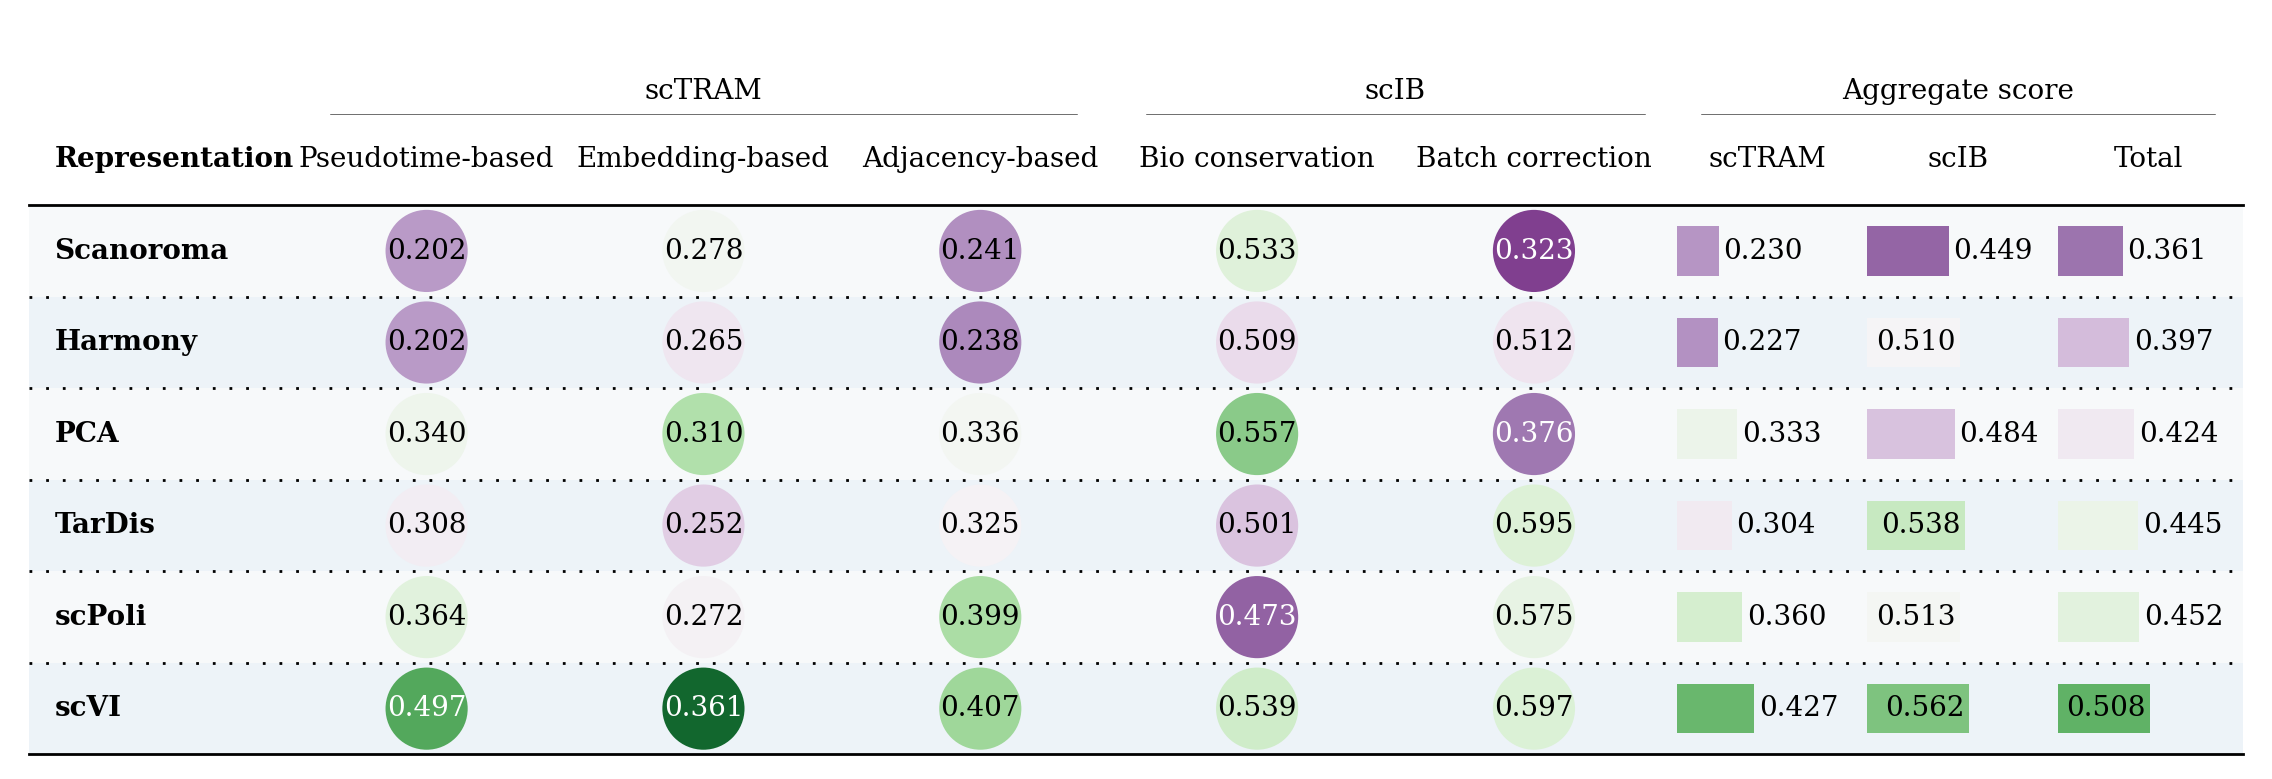

In [56]:
df_plot = summary_T.reset_index().copy()
df_plot_dict = {f"{lvl0}\n{lvl1}": (lvl0, lvl1) for (lvl0, lvl1) in df_plot.columns}
df_plot.columns = [f"{lvl0}\n{lvl1}" for (lvl0, lvl1) in df_plot.columns]

cmap_fn = lambda col_data: normed_cmap(col_data, cmap=cm.PRGn, num_stds=2.5)

col_defs = []
for col in df_plot.columns:
    # Create a “normalized color map” for this column:
    lvl0, lvl1 = df_plot_dict[col]
    if lvl0 == "Aggregate score" or lvl0 == "Representation":
        continue
    cmap = cmap_fn(df_plot[col])

    cd = ColumnDefinition(
        name=col,  # Must exactly match the flattened column name in df_plot
        width=0.8,  # width of each column in inches (tweak as needed)
        cmap=cmap,  # cell background colormap (normed by this column’s values)
        text_cmap=cmap,  # text color also follows same colormap
        textprops={
            "ha": "center",
            "bbox": {"boxstyle": "circle", "pad": 0},
        },
        group=lvl0,
        title=lvl1,
        formatter="{:.3f}".format,  # three decimal places
    )
    col_defs.append(cd)

i = 0
for col in df_plot.columns:
    # Create a “normalized color map” for this column:
    lvl0, lvl1 = df_plot_dict[col]
    if lvl0 != "Aggregate score" or lvl0 == "Representation":
        continue
    cmap = cmap_fn(df_plot[col])
    i += 1

    c_min = min(df_plot[col])
    c_max = max(df_plot[col])
    cmap = cmap_fn(df_plot[col])

    cd = ColumnDefinition(
        name=col,
        width=0.55,
        plot_fn=bar,
        plot_kw={
            "cmap": cmap, #cm.YlGnBu,
            "plot_bg_bar": False,
            # "xlim": [c_min, c_max],
            "annotate": True,
            "height": 0.9,
            "formatter": "{:.3f}",
            "textprops": {"fontsize": 10}
        },
        group=lvl0,
        title=lvl1,
        border="left" if i == 0 else None,
    )
    col_defs.append(cd)

col_defs += [ColumnDefinition(name="Representation\n", title="Representation", width=0.75, textprops={"ha": "left", "weight": "bold"})]

# Allow to manipulate text post-hoc (in illustrator)
with mpl.rc_context({"svg.fonttype": "none"}):
    fig, ax = plt.subplots(figsize=(len(summary_T.columns) * 1.8, 3 + 0.3 * len(summary_T.index)))
    tab = Table(
        df_plot,
        cell_kw={
            "linewidth": 0,
            "edgecolor": "k",
        },
        row_dividers=True,
        footer_divider=True,
        textprops={"fontsize": 10, "ha": "center"},
        row_divider_kw={"linewidth": 1, "linestyle": (0, (1, 5))},
        col_label_divider_kw={"linewidth": 1, "linestyle": "-"},
        column_border_kw={"linewidth": 1, "linestyle": "-"},
        column_definitions=col_defs,
        even_row_color="#f7f9fa",
        odd_row_color="#edf3f8",
        ax=ax,
        index_col="Representation\n",
    ).autoset_fontcolors(colnames=df_plot.columns)

    plt.show()